Citations

Investment Management with Python and Machine Learning Specialization,EDHEC Business School,https://www.coursera.org/specializations/investment-management-python-machine-learning?#instructors

Martin, R. A., (2021). PyPortfolioOpt: portfolio optimization in Python. Journal of Open Source Software, 6(61), 3066, https://doi.org/10.21105/joss.03066

Yijuan Lu, Ira Cohen, Xiang Sean Zhou,Qi Tian; May 27, 2021, Feature Selection Using Principal Feature Analysis,http://venom.cs.utsa.edu/dmz/techrep/2007/CS-TR-2007-011.pdf

This notebook is an implementation of several algorithms and machine learning models in a process designed to create an actual investment portfolio.
It lays a foundation for more robust application in real practice. After backtesing I found that it has no real edge I think this is due to the fact that I pick stocks based on diversification rather than some other underlying factor or estimation. I do not use my return estimations to pick stocks I only apply my views after I have allready chosen stocks based on the PFA analysis below. You could first isolate a group of stocks based on your own strategy and then apply the same procedure and it would be much more useful. I just wanted to create a full process that takes raw data and creates an actual allocation of stocks using machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as pyplot
import requests
from collections import Counter
import time
from tqdm import tqdm
import csv
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dateutil.relativedelta import relativedelta
import xgboost as xgb
from datetime import date
from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from matplotlib.pyplot import figure
import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from scipy.fft import fft, fftfreq, fftshift, rfft
from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tools.eval_measures import rmse
from sklearn.preprocessing import MaxAbsScaler
from arch import arch_model
import quandl

plt.rcParams.update({'font.size':18})
plt.rcParams['figure.figsize'] = [40,10]

import warnings
warnings.filterwarnings('ignore')

In [2]:
##function to call any given url in json format
def call(url):
    r = requests.get(url)
    json_data = r.json()
    return(json_data)

In [3]:
###URL_LOOP creates a dict of URLs for each ticker in a given list, must be run for each call. Make sure the original URL uses 'AAPL' as the default ticker.
def url_loop(url,listr):
  listr_l = {}
  for i in listr:
    listr_l[i] = url.replace('AAPL',i)
  return listr_l

In [4]:
from datetime import date


today = date.today()
print("Today's date:", today)

Today's date: 2021-07-24


In [6]:
##EODHISTORICAL URL's: add &fmt=json to end of each for use in 'call'
fundamentals_url = 'https://eodhistoricaldata.com/api/fundamentals/AAPL.US?api_token=#########'
SP500_hist_constituants = 'https://eodhistoricaldata.com/api/fundamentals/GSPC.INDX?api_token=########'
OHLC_URL = 'https://eodhistoricaldata.com/api/eod/AAPL.US?from=2000-01-01&to='+str(today)+'&api_token=#######'
spy_url = 'https://eodhistoricaldata.com/api/eod/SPY.US?from=2000-01-01&to'+str(today)+'&api_token=########'

In [8]:
##S&P 500 historical componants
hist_const = call(SP500_hist_constituants)
#FIRST LAYER
hc_gen = hist_const['General']
cc_list =  hist_const['Components']
hc_dict = hist_const['HistoricalTickerComponents']
#CURRENT SECTORS and INDUSTRIES
sector_ind_df = pd.DataFrame(hc_dict)
sector_ind_df.T
ticker_list=sector_ind_df.T['Code']
#CURRENT COMPONENTS of SP500
ccdf = pd.DataFrame(cc_list)
cc_ticker_list = ccdf.T['Code']

In [9]:
## GICS SECTORS AND INDUSTRIES
def gics(tckr):
    gics = {}
    code = pd.Series(fundamental_dic[tckr]['General']['Code'])
    gics_group = pd.Series(fundamental_dic[tckr]['General']['GicGroup'])
    gics_sector = pd.Series(fundamental_dic[tckr]['General']['GicIndustry'])
    gics_industry = pd.Series(fundamental_dic[tckr]['General']['GicSubIndustry'])
    gics_df = pd.concat([code,gics_group,gics_sector,gics_industry],axis=1)
    gics_df.columns = ['Code','gics_group','gics_sector','gics_industry']
    return gics_df

In [10]:
def change_duplicates(df,col):
    '''
    Full credit to https://datascience.stackexchange.com/questions/41448/how-to-rename-columns-that-have-the-same-name
    '''
    cols = []
    count = 1
    for column in df.columns:
        if column == 'Index':
            cols.append(f'Index_{count}')
            count+=1
            continue
        cols.append(column)
    df.columns = cols
    return df

I include a long list of macroeconomic timeseries. I hope this publicly available data will help give accuracy to my return estimations.

In [11]:
ISM_MAN = {'PMI':quandl.get("ISM/MAN_PMI", authtoken="###"),'new_orders':quandl.get("ISM/MAN_NEWORDERS", authtoken="####"),'employment':quandl.get("ISM/MAN_EMPL", authtoken="###"),'production':quandl.get("ISM/MAN_PROD", authtoken="####"),'deliveries':quandl.get("ISM/MAN_DELIV", authtoken="####"),'inventories':quandl.get("ISM/MAN_INVENT", authtoken="#####"),'customer_inventories':quandl.get("ISM/MAN_CUSTINV", authtoken="####"),'prices':quandl.get("ISM/MAN_PRICES", authtoken="####"),'backlog':quandl.get("ISM/MAN_BACKLOG", authtoken="####"),'imports':quandl.get("ISM/MAN_IMPORTS", authtoken="####"),'exports':quandl.get("ISM/MAN_EXPORTS", authtoken="####")}
ISM_NON_MAN = {'NMI':quandl.get("ISM/NONMAN_NMI", authtoken="####"),'business_activity':quandl.get("ISM/NONMAN_BUSACT", authtoken="####"),'new_orders':quandl.get("ISM/NONMAN_NEWORD", authtoken='####''),'employment':quandl.get("ISM/NONMAN_EMPL", authtoken="####"),'deliveries':quandl.get("ISM/NONMAN_DELIV", authtoken=####"),'inventories':quandl.get("ISM/NONMAN_INVENT", authtoken="#####"),'inventory_sentiment':quandl.get("ISM/NONMAN_INVSENT", authtoken="####"),'backlog':quandl.get("ISM/NONMAN_BACKLOG", authtoken="####"),'prices':quandl.get("ISM/NONMAN_PRICES", authtoken="####"),'imports':quandl.get("ISM/NONMAN_IMPORTS", authtoken="####"),'exports':quandl.get("ISM/NONMAN_EXPORTS", authtoken="####")}

PMI_col_list = ['new_orders_% Better','new_orders_% Same','new_orders_% Worse','new_orders_Net','new_orders','PMI','Index_% Higher','Index_% Same','Index_% Lower','Index_Net','Index','production_% Better',
      'production_% Same','production_% Worse','production_Net','production','deliveries_% Slower','deliveries_% Same','deliveries_% Faster','deliveries_Net','deliveries','inventories_% Higher',
      'inventories_% Same','inventories_% Lower','inventories_Net','inventories','consumer_inventories_% Too High','consumer_inventories_% About Right','consumer_inventories_% Too Low',
      'consumer_inventories_Net','consumer_inventories','price_% Reporting','price_% Higher','price_% Same','price_% Lower','price_Net','price','backlog_% Reporting','backlog_% Greater',
      'backlog_% Same','backlog_% Less','backlog_Net','backlog','imports_% Reporting','imports_% Higher','imports_% Same','imports_% Lower','imports_Net','imports','exports_% Reporting',
      'exports_% Greater','exports_% Same','exports_%Lower', 'exports_Net','exports','PMI_exports_% Reporting']


ISM_MAN_list = []
PMI_list = ['new_orders','PMI','employment','production','deliveries','inventories','customer_inventories','prices','backlog','imports','exports']
for i in PMI_list:
    ISM_MAN_DF = pd.DataFrame(ISM_MAN[i])
    ISM_MAN_list.append(ISM_MAN_DF)
ISM_MAN_DF = pd.concat(ISM_MAN_list, axis=1)
ISM_MAN_DF.columns = PMI_col_list

ISM_NMAN_list = []
NMI_list = ['NMI','business_activity','new_orders','employment','inventories','inventory_sentiment','backlog','prices','imports','exports']
col_names = [{'Index':'NMI'},{'% Higher':'bus_act_%Higher','% Same':'bus_act_%Same','% Lower':'bus_act_%Lower','Diffusion Index':'buisness_activity'},
    {'% Higher':'new_ord_%Higher','% Same':'new_ord_%Same','% Lower':'new_order_%Lower','Diffusion Index':'NMI_new_orders'},
    {'% Higher':'employment_%Higher','% Same':'employment_%Same','% Lower':'employment_%Lower','Diffusion Index':'NMI_employment'},
    {'% Higher':'inventories_%Higher','% Same':'inventories_%Same','% Lower':'inventories_%Lower','Diffusion Index':'NMI_inventories'},
    {'% Too High':'inventory_sentiment_TooHigh','% About Right':'inventory_sentiment_%About_Right','% Too Low':'inventory_sentiment_%TooLow','Diffusion Index':'inventory_sentiment'},
    {'% Higher':'backlog_%Higher','% Same':'backlog_%Same','% Lower':'backlog_%Lower','Diffusion Index':'NMI_backlog'},
    {'% Higher':'prices_%Higher','% Same':'prices_%Same','% Lower':'prices_%Lower','Diffusion Index':'prices'},
    {'% Higher':'imports_%Higher','% Same':'imports_%Same','% Lower':'NMI_imports_%Lower','Diffusion Index':'NMI_imports'},
    {'% Higher':'exports_%Higher','% Same':'exports_%Same','% Lower':'NMI_exports_%Lower','Diffusion Index':'NMI_exports'}]
for i,c in zip(NMI_list,col_names):
    ISM_NMAN_DF = pd.DataFrame(ISM_NON_MAN[i])
    ISM_NMAN_DF = ISM_NMAN_DF.rename(columns=(c))
    ISM_NMAN_list.append(ISM_NMAN_DF)
    
ism_non_man_df  = pd.concat(ISM_NMAN_list, axis=1)
ism_non_man_df 

#pull from Quandl
UMCSENT = quandl.get("UMICH/SOC1", authtoken="####")
BUILD_PERMITS =quandl.get("FRED/PERMIT", authtoken="####")
IR_SPREAD_T10Y3M = quandl.get("FRED/T10Y3M", authtoken="####")
IR_SPREAD_T10Y2Y = quandl.get("FRED/T10Y2Y", authtoken="####")
CPI = quandl.get("FRED/CPIAUCSL", authtoken="#####")
medical_CPI = quandl.get("FRED/CPIMEDSL", authtoken="######")
M2 = quandl.get("FRED/M2REAL", authtoken='#####")
M1 = quandl.get("FRED/M1REAL", authtoken="####")
Real_GDP = quandl.get("FRED/GDPC1", authtoken="####")
t_bill = quandl.get("FRED/WTB3MS",authtoken='#####")
T10YFFM = quandl.get("FRED/T10YFFM",authtoken="####")


#create DFs and rename columns
umcsent = pd.DataFrame(UMCSENT)
umcsent = umcsent.rename(columns={'Index':'umcsent'})
#
BUILD_PERMITS_df = pd.DataFrame(BUILD_PERMITS)
build_permits = BUILD_PERMITS_df.rename(columns={'Value':'Build_Permits'})
#
T10Y3M_df = pd.DataFrame(IR_SPREAD_T10Y3M)
T10Y3M = T10Y3M_df.rename(columns={'Value':'T10Y3M'})
#
T10Y2Y_df = pd.DataFrame(IR_SPREAD_T10Y2Y)
T10Y2Y = T10Y2Y_df.rename(columns={'Value':'T10Y2Y'})
#
CPI = pd.DataFrame(CPI)
CPI=CPI.rename(columns={'Value':'CPI'})
#
medical_CPI = pd.DataFrame(medical_CPI)
medical_CPI = medical_CPI.rename(columns={'Value':'MED_CPI'})
#
M2 = pd.DataFrame(M2)
M2 = M2.rename(columns={'Value':'M2'})
#
M1 = pd.DataFrame(M1)
M1 = M1.rename(columns={'Value':'M1'})
#
Real_GDP = pd.DataFrame(Real_GDP)
Real_GDP = Real_GDP.rename(columns={'Value':'R_GDP'})
#                  
t_bill = pd.DataFrame(t_bill)
t_bill = t_bill.rename(columns={'Value':'T_Bill'})

T10YFFM = pd.DataFrame(T10YFFM)
T10YFFM = T10YFFM.rename(columns={'Value':'T10YFFM'})

#call spy place in DF
spy = call(spy_url)
spy = pd.DataFrame(spy)
spy = spy[['adjusted_close','date']].set_index('date')
spy = spy.rename(columns={'adjusted_close':'spy_close'})
spy

econ_df_fill = pd.concat([spy,ISM_MAN_DF,ism_non_man_df,umcsent,build_permits,T10Y3M,T10Y2Y,CPI,medical_CPI,M2,M1,Real_GDP,t_bill,T10YFFM], axis = 1).fillna(method ='ffill')
econ_df_fill.index = pd.to_datetime(econ_df_fill.index)
econ_df_fill = change_duplicates(econ_df_fill,'Index')
econ_df_fill

,spy_close,new_orders_% Better,new_orders_% Same,new_orders_% Worse,new_orders_Net,new_orders,PMI,Index_% Higher,Index_% Same,Index_% Lower,...,Build_Permits,T10Y3M,T10Y2Y,CPI,MED_CPI,M2,M1,R_GDP,T_Bill,T10YFFM
1947-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,21.480,13.200,NaN,NaN,2033.061,NaN,NaN
1947-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,21.620,13.300,NaN,NaN,2033.061,NaN,NaN
1947-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,22.000,13.300,NaN,NaN,2033.061,NaN,NaN
1947-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,22.000,13.400,NaN,NaN,2027.639,NaN,NaN
1947-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,21.950,13.500,NaN,NaN,2027.639,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-19,424.97,42.1,49.7,8.2,33.9,66.0,60.6,26.6,54.1,19.3,...,1598.0,1.25,1.08,270.981,523.058,7585.2,7157.6,19086.375,0.05,1.44
2021-07-20,431.06,42.1,49.7,8.2,33.9,66.0,60.6,26.6,54.1,19.3,...,1598.0,1.25,1.08,270.981,523.058,7585.2,7157.6,19086.375,0.05,1.44
2021-07-21,434.55,42.1,49.7,8.2,33.9,66.0,60.6,26.6,54.1,19.3,...,1598.0,1.25,1.08,270.981,523.058,7585.2,7157.6,19086.375,0.05,1.44
2021-07-22,435.46,42.1,49.7,8.2,33.9,66.0,60.6,26.6,54.1,19.3,...,1598.0,1.25,1.08,270.981,523.058,7585.2,7157.6,19086.375,0.05,1.44


In [12]:
## GICS SECTORS AND INDUSTRIES
def gics(tckr):
    gics = {}
    fundamental_dic =  call(fundamentals_url_dict[tckr])
    code = pd.Series(fundamental_dic['General']['Code'])
    gics_group = pd.Series(fundamental_dic['General']['GicGroup'])
    gics_sector = pd.Series(fundamental_dic['General']['GicIndustry'])
    gics_industry = pd.Series(fundamental_dic['General']['GicSubIndustry'])
    gics_df = pd.concat([code,gics_group,gics_sector,gics_industry],axis=1)
    gics_df.columns = ['Code','gics_group','gics_sector','gics_industry']
    return gics_df

In [13]:
#URL LOOPS
div_url_dict = url_loop(dividends_url,ticker_list)
fundamentals_url_dict = url_loop(fundamentals_url,ticker_list)
ohlc_url_dict = url_loop(OHLC_URL,ticker_list)

In [14]:
#DF of gics sectors and industries combined
SP500_gics = pd.DataFrame()
for i in tqdm(fundamentals_url_dict.keys()):
    try:
        row_to_add = gics(i)
        SP500_gics = SP500_gics.append(row_to_add)
    except KeyError:
        print(i)
        continue

SP500 = SP500_gics[['Code','gics_sector','gics_group']].set_index('Code')

  3%|██▌                                                                              | 26/826 [00:20<09:47,  1.36it/s]

AET


 16%|█████████████▏                                                                  | 136/826 [01:48<06:21,  1.81it/s]

CBH


 38%|██████████████████████████████▏                                                 | 312/826 [04:10<05:29,  1.56it/s]

FPL


 81%|█████████████████████████████████████████████████████████████████               | 672/826 [08:57<01:33,  1.64it/s]

SHLD


100%|████████████████████████████████████████████████████████████████████████████████| 826/826 [10:59<00:00,  1.25it/s]


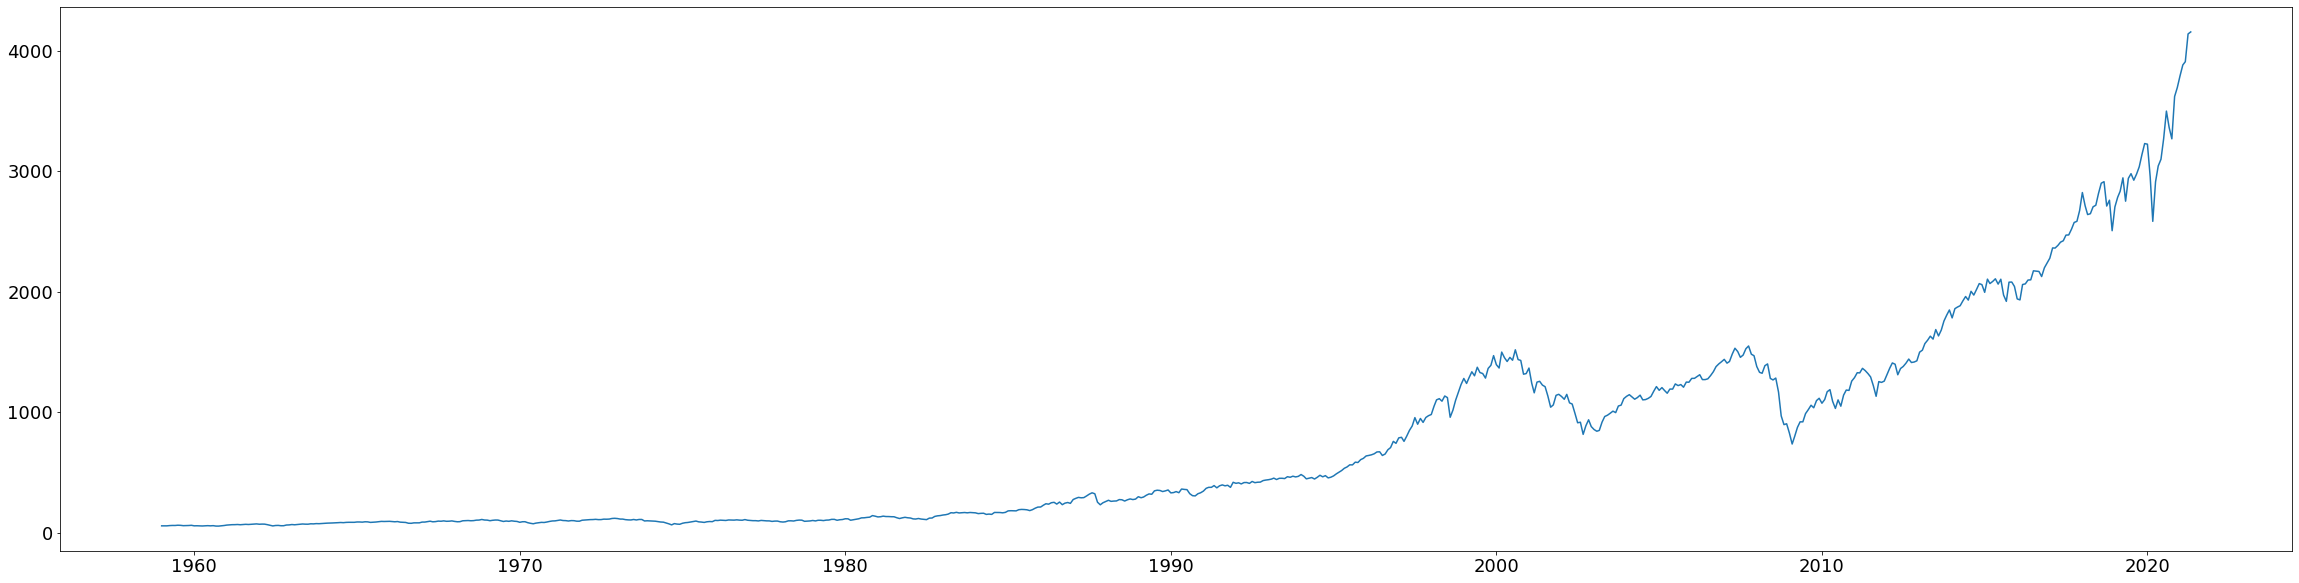

In [15]:
# History of the S&P 500 the index I use as a benchmark for my portfolio.
S_P_hist = pd.read_csv(r'E:\portfolio\lab sesisons week 2; 4 and 5 April 2021 NEW VERSION\Jupyter notebooks\Module 5 - April2021\data\sp500.csv')
h_df = S_P_hist[['Date','Adj Close']]

S_P_Current = pd.read_excel(r"E:\Mandelbrot_code\Mandelbrot\Mandelbrot\SP500_05_22_21.xls")
c_df = S_P_Current.iloc[10:]
c_df.columns = ['Date','Adj Close']


h_df = h_df.set_index('Date')
h_df.index = pd.to_datetime(h_df.index)
d = h_df.iloc[-1].name
h_df = h_df.iloc[:-1]

c_df = c_df.set_index('Date')
c_df.index = pd.to_datetime(c_df.index)
c_df = c_df.astype(float)
c_df = c_df.resample('MS').mean()
c_df = c_df.loc[str(d):]

plt.figure(figsize=(40,10))
SP_Index = pd.concat([h_df,c_df], axis = 0)
plt.plot(SP_Index.astype(float))
plt.show()

In [17]:
#Different sectors within the S&P 500
sector = pd.DataFrame(SP500,columns=['gics_sector','gics_group'])
sector.columns = ['Name','Sector']
sector

,Name,Sector
Code,,
A,Life Sciences Tools & Services,"Pharmaceuticals, Biotechnology & Life Sciences"
AA,Metals & Mining,Materials
AABA,Internet & Direct Marketing Retail,Retailing
AAL,Airlines,Transportation
AAP,Specialty Retail,Retailing
...,...,...
YUM,"Hotels, Restaurants & Leisure",Consumer Services
ZBH,Health Care Equipment & Supplies,Health Care Equipment & Services
ZBRA,"Electronic Equipment, Instruments & Components",Technology Hardware & Equipment


In [18]:
##remove bad tickers, data is not complete.
L3 = [fundamentals_url_dict,div_url_dict,ohlc_url_dict]
L4 = ['EK','WFR','KFT','BRK','FNM']
for f,j in zip(L3,L4):
    f.pop(j)

In [19]:
###Financial measurements of each underlying company. They are crudely calculated but give me the underlying value I’m looking for.
fund_error_list = []
clean_fund_df_dict = {}
for k,v in tqdm(fundamentals_url_dict.items()):
    df = call(v)
    try:
        df1 = pd.DataFrame(df['Financials']['Balance_Sheet']['quarterly'])
        df2 = pd.DataFrame(df['Financials']['Income_Statement']['quarterly'])
        df3 = pd.DataFrame(df['Financials']['Cash_Flow']['quarterly'])
        df4 = pd.concat([df1.T,df2.T,df3.T],axis=1)
        df4 =df4.loc[:,~df4.columns.duplicated()]
        df4 = df4.set_index('date')
        df4.index = pd.to_datetime(df4.index)
        df4.index = df4.index - pd.offsets.MonthBegin(0)
        df_ex_1 = df4[['commonStock','commonStockSharesOutstanding','totalCashFromOperatingActivities','totalCurrentAssets',
        'totalCurrentLiabilities','totalAssets','totalLiab','totalStockholderEquity','netIncome','totalRevenue','ebit','grossProfit','operatingIncome']]
        df_ex_1 = df_ex_1.apply(pd.to_numeric, errors='ignore')
        df_ex_1['book_value_pershare'] = (df_ex_1['totalAssets'] - df_ex_1['totalLiab'])/df_ex_1['commonStock']
        df_ex_1['operating_cashflow_pershare'] = (df_ex_1['totalCashFromOperatingActivities']/df_ex_1['commonStock'])
        df_ex_1['current_ratio'] = (df_ex_1['totalCurrentAssets']/df_ex_1['totalCurrentLiabilities'])
        df_ex_1['cash_ratio'] = (df_ex_1['totalCashFromOperatingActivities']/df_ex_1['totalCurrentLiabilities'])
        df_ex_1['ROE'] = (df_ex_1['netIncome']/df_ex_1['totalStockholderEquity'])
        df_ex_1['ROA'] = (df_ex_1['netIncome']/df_ex_1['totalAssets'])
        df_ex_1['gross_profit_margin'] = (df_ex_1['grossProfit']/df_ex_1['totalRevenue'])
        df_ex_1['operating_profit_margin'] = (df_ex_1['operatingIncome']/df_ex_1['totalRevenue'])
        df_ex_1['net_profit_margin'] = (df_ex_1['netIncome']/df_ex_1['totalRevenue'])
        df_ex_1['pre_tax_margin'] = (df_ex_1['ebit']/df_ex_1['totalRevenue'])
        clean_fund_df_dict[k] = df_ex_1
    except KeyError:
        fund_error_list.append(k)
        continue

100%|████████████████████████████████████████████████████████████████████████████████| 825/825 [11:18<00:00,  1.22it/s]


In [20]:
#Extracting earnings 
def eps_df(fundamentals_url_dict):
    eps_df_raw={}
    for k,v in tqdm(fundamentals_url_dict.items()):
        df = call(v)
        try:
            eps_df = pd.DataFrame(df['Earnings']['History']).T
            eps_df = eps_df.set_index('date')
            eps_df.index = pd.to_datetime(eps_df.index)
            eps_df.index = eps_df.index - pd.offsets.MonthBegin(0)
            eps_df = eps_df[['epsActual','epsEstimate','epsDifference','surprisePercent']]
            eps_df_raw[k] = eps_df
        except KeyError:
            pass
    return(eps_df_raw)

In [21]:
eps = eps_df(fundamentals_url_dict)

100%|████████████████████████████████████████████████████████████████████████████████| 825/825 [11:05<00:00,  1.24it/s]


In [22]:
## Create a dictionary of all OHLC data
ohlc_dict = {}
for k,v in tqdm(ohlc_url_dict.items()):
    ohlc_dict[k] = call(v)

## OHLC dataframe for each ticker
ohlc_df = {}
for i in tqdm(ohlc_dict.keys()):
    ohlc_df[i] = pd.DataFrame(ohlc_dict[i], columns = ['date','open','high','low','adjusted_close','volume']).set_index('date')
    
#Create SMA for each stock
tckr_list = list(ohlc_df.keys())
day_list = [8,21,63,252]
column_list=['8_SMA','21_SMA','63_SMA','252_SMA']

for i in tqdm(tckr_list):
    for t,l in zip(day_list,column_list):
        ohlc_df[i][l] = ohlc_df[i]['adjusted_close'].rolling(window = t).mean()

100%|███████████████████████████████████████████████████████████████████████████████| 825/825 [00:01<00:00, 464.79it/s]


Here I combine all exogenous data for each stock in its own data frame, this is essential for individual forecasts which are needed to differentiate between stocks in the index.

In [23]:
def merge(tckr,econ_df_fill):
    df1 = clean_fund_df_dict[tckr]
    df2 = ohlc_df[tckr]
    df2.index = pd.to_datetime(df2.index)
    df4 = eps[tckr]
    df5 = pd.concat([df4,df2],axis=1)
    df5 = df5.loc[df2.index]
    df6 =  pd.concat([df5,df1],axis=1)
    econ_df_fill = econ_df_fill.loc[~econ_df_fill.index.duplicated(keep='first')]
    df7 = pd.concat([df6,econ_df_fill],axis=1)
    df10 = df7.fillna(method='ffill')
    return df10

In [24]:
#Preprocessing and storage
#Complete dataframes packed in an easy dictionary
f_dict = {}
# Exception_list, for further study and data cleaning
ex_list = []
#Drop list, need to drop these because they have too many missing values.
drop_list = list(["commonStockSharesOutstanding","totalCurrentAssets","backlog_% Reporting","NMI"])

for i in tqdm(ticker_list):
    try:
        f_dict[i] = merge(i,econ_df_fill).drop(drop_list,axis=1).dropna()
        f_dict[i] = f_dict[i].loc[:'2010-01-01']
    except:
        ex_list.append(i)
        

100%|████████████████████████████████████████████████████████████████████████████████| 826/826 [00:47<00:00, 17.40it/s]


In [25]:
f_dict['IBM']

,epsActual,epsEstimate,epsDifference,surprisePercent,open,high,low,adjusted_close,volume,8_SMA,...,Build_Permits,T10Y3M,T10Y2Y,CPI,MED_CPI,M2,M1,R_GDP,T_Bill,T10YFFM
2001-10-01,0.9,0.89,0.01,1.1236,91.72,93.48,91.34,58.0939,8676200.0,57.874538,...,1566.0,2.18,1.73,177.600,276.300,3005.0,656.4,13280.859,2.34,2.08
2001-10-02,0.9,0.89,0.01,1.1236,92.30,93.90,92.10,58.7581,7221200.0,57.903525,...,1566.0,2.27,1.76,177.600,276.300,3005.0,656.4,13280.859,2.34,2.08
2001-10-03,0.9,0.89,0.01,1.1236,92.90,97.62,92.40,60.7507,11118800.0,58.408738,...,1566.0,2.27,1.73,177.600,276.300,3005.0,656.4,13280.859,2.34,2.08
2001-10-04,0.9,0.89,0.01,1.1236,97.15,98.88,96.80,60.9763,9785100.0,58.605337,...,1566.0,2.32,1.78,177.600,276.300,3005.0,656.4,13280.859,2.34,2.08
2001-10-05,0.9,0.89,0.01,1.1236,96.65,98.45,95.37,61.4212,9733000.0,58.884963,...,1566.0,2.33,1.81,177.600,276.300,3005.0,656.4,13280.859,2.21,2.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-28,2.4,2.38,0.02,0.8403,130.99,132.31,130.72,91.4095,5801087.0,89.423262,...,664.0,3.74,2.76,217.347,381.111,3909.1,778.8,15356.058,0.07,3.47
2009-12-29,2.4,2.38,0.02,0.8403,132.28,132.37,131.80,91.0917,4184782.0,89.694425,...,664.0,3.72,2.73,217.347,381.111,3909.1,778.8,15356.058,0.07,3.47
2009-12-30,2.4,2.38,0.02,0.8403,131.23,132.68,130.68,91.5892,3867291.0,90.140912,...,664.0,3.75,2.72,217.347,381.111,3909.1,778.8,15356.058,0.07,3.47
2009-12-31,2.4,2.38,0.02,0.8403,132.41,132.85,130.75,90.4354,4225128.0,90.399125,...,664.0,3.79,2.71,217.347,381.111,3909.1,778.8,15356.058,0.07,3.47


In [26]:
def lag_gen(lags,df):
    df_list = []
    sb = []
    for l in lags:
        df1 = df
        df2 = df1.shift(periods=l)
        df2.columns = df2.columns+str(' t-'+str(l))
        df_list.append(df2)
    df3 = pd.concat(df_list,axis=1)
    return(df3)

In [27]:
# Lag gen is used to create timeseries data for the larger model
appl_lag = lag_gen([0,1,2,3,4],f_dict['AAPL'])
appl_lag

,epsActual t-0,epsEstimate t-0,epsDifference t-0,surprisePercent t-0,open t-0,high t-0,low t-0,adjusted_close t-0,volume t-0,8_SMA t-0,...,Build_Permits t-4,T10Y3M t-4,T10Y2Y t-4,CPI t-4,MED_CPI t-4,M2 t-4,M1 t-4,R_GDP t-4,T_Bill t-4,T10YFFM t-4
2002-07-01,0.010,0.01,0.000,0.0,17.7100,17.8808,17.0492,0.2620,222689590.0,0.262500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-02,0.010,0.01,0.000,0.0,17.0296,17.1612,16.8308,0.2601,305188787.0,0.262175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-03,0.010,0.01,0.000,0.0,16.8112,17.6792,16.7496,0.2695,199029591.0,0.263525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-05,0.010,0.01,0.000,0.0,17.7100,18.7488,17.7100,0.2878,161593593.0,0.266350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-07-08,0.010,0.01,0.000,0.0,18.5192,18.6088,17.6792,0.2766,211203991.0,0.268025,...,1738.0,3.13,1.97,180.000,286.400,3105.1,666.2,13538.072,1.68,2.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-28,0.065,0.05,0.015,30.0,211.7200,213.9500,209.6112,6.4988,644564172.0,6.156300,...,664.0,3.68,2.81,217.347,381.111,3909.1,778.8,15356.058,0.04,3.47
2009-12-29,0.065,0.05,0.015,30.0,212.6300,212.7200,208.7300,6.4217,445204181.0,6.210313,...,664.0,3.70,2.81,217.347,381.111,3909.1,778.8,15356.058,0.04,3.47
2009-12-30,0.065,0.05,0.015,30.0,208.8300,212.0000,208.3100,6.4997,412082702.0,6.286238,...,664.0,3.77,2.82,217.347,381.111,3909.1,778.8,15356.058,0.04,3.47
2009-12-31,0.065,0.05,0.015,30.0,213.1300,213.3500,210.5600,6.4718,352410785.0,6.344975,...,664.0,3.77,2.82,217.347,381.111,3909.1,778.8,15356.058,0.07,3.47


In [32]:
def return_gen(df,resample):
    df = df.resample(resample).mean().pct_change()
    df = df.replace([np.inf,-np.inf],np.nan)
    df = df.interpolate(method='linear')
    df = df.dropna()
    return df

In [33]:
#Sector_dict for One Hot Encoding
sec = {}
for i in f_dict.keys():
    sec[i] = SP500['gics_group'].loc[i]

In [34]:
##Dickey FUller test
#With the ADF test, the "null hypothesis" (the hypothesis that we either reject or fail to reject)
#is that the series follows a random walk. Therefore, a low p-value (say less than 5%) means we can 
#reject the null hypothesis that the series is a random walk.
## AUGMENTED DICKEY FULLER TEST
from statsmodels.tsa.stattools import adfuller
def dickey_fuller(resid):
    ls_df_ar = resid[~np.isnan(resid)]
    results = adfuller(np.array(ls_df_ar))
    #P-VALUE DF test
    print('The test statistic is: '+str(results[0]))
    print('The p-value of the test statististic is: ' + str(results[1]))
    if results[1] < 0.05:
        print("Because the P_value is < 0.05 we can claim this data array is stationary")
    else:
        print("Because the P_value is > 0.05 we can claim this data array is NOT stationary")
    return(results[1])

In [35]:
stationary = {}
not_stationary = {}
for i in f_dict['IBM'].columns:
    print(str(i))
    if dickey_fuller(f_dict['IBM'][i]) < 0.05:
        stationary[str(i)] =  dickey_fuller(f_dict['IBM'][i])
    else:
        not_stationary[str(i)] =  dickey_fuller(f_dict['IBM'][i])

epsActual
The test statistic is: -0.21926777130897782
The p-value of the test statististic is: 0.9361856402026324
Because the P_value is > 0.05 we can claim this data array is NOT stationary
The test statistic is: -0.21926777130897782
The p-value of the test statististic is: 0.9361856402026324
Because the P_value is > 0.05 we can claim this data array is NOT stationary
epsEstimate
The test statistic is: -0.06734529809073447
The p-value of the test statististic is: 0.9525954896037112
Because the P_value is > 0.05 we can claim this data array is NOT stationary
The test statistic is: -0.06734529809073447
The p-value of the test statististic is: 0.9525954896037112
Because the P_value is > 0.05 we can claim this data array is NOT stationary
epsDifference
The test statistic is: -3.6796631349317988
The p-value of the test statististic is: 0.004408476081265327
Because the P_value is < 0.05 we can claim this data array is stationary
The test statistic is: -3.6796631349317988
The p-value of the 

In [36]:
ap_r_ex = return_gen(f_dict['AAPL'],'21d')
var_ex = var_gen(f_dict['AAPL'],ap_r_ex,'adjusted_close') # Looks like crap

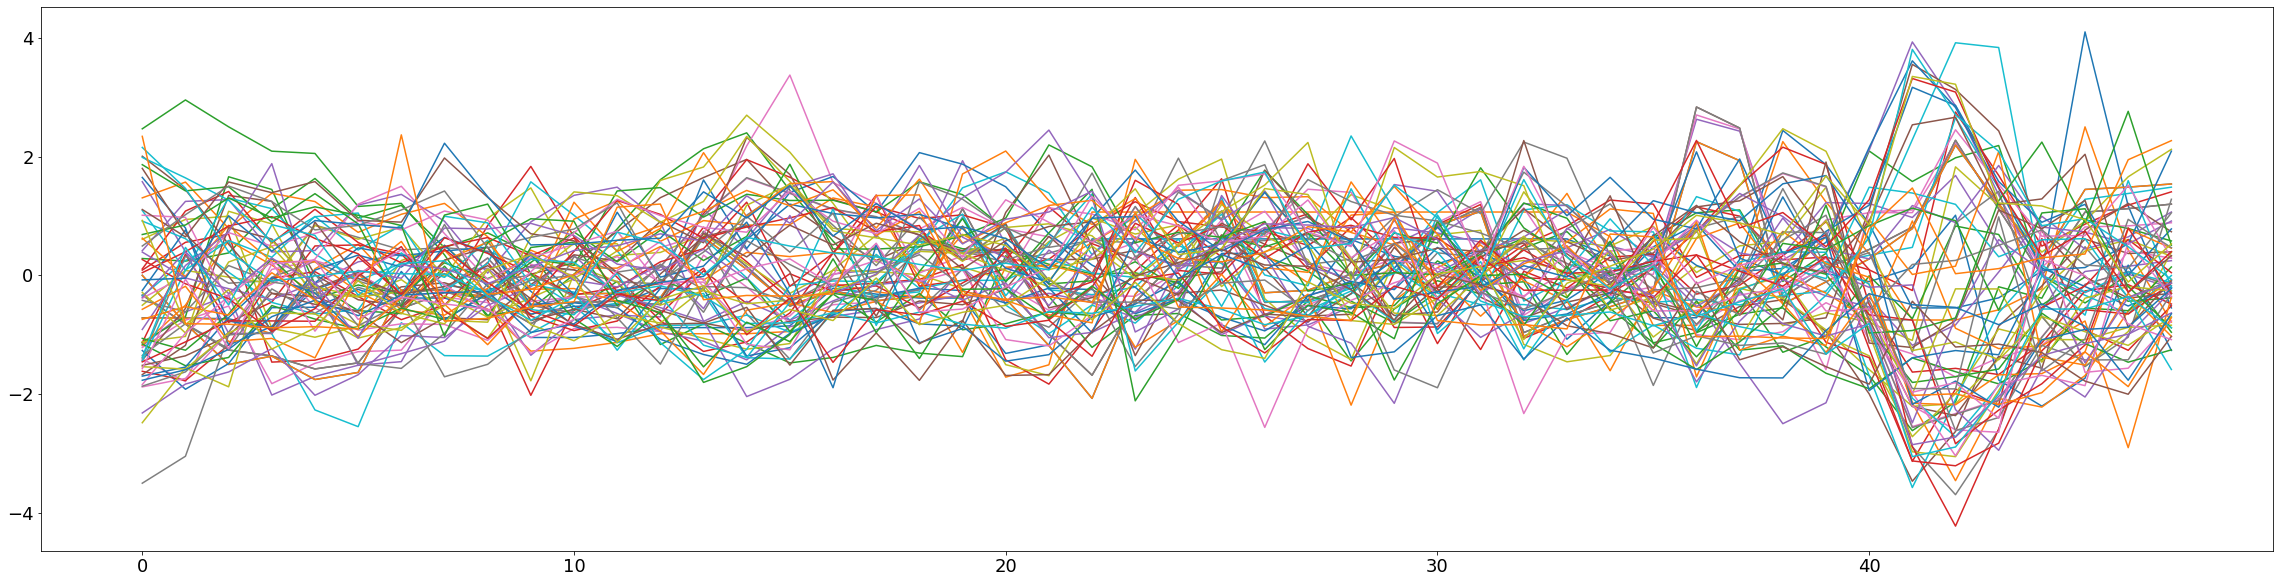

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

n_ret = f_dict['IBM'][stationary.keys()].resample('63d').mean()
plt.plot(scaler.fit_transform(n_ret))
plt.show()

In [39]:
##BIG_BLOCK
def big_block(f_dict,interval,lag,target,var_target,stationary,not_stationary,scaler):
    df_list = []
    n_dict = {}
    valid = {}
    for t in tqdm(f_dict.keys()):
        ret = return_gen(f_dict[t][not_stationary.keys()],interval)
        nret = f_dict[t][stationary.keys()].resample(interval).mean()
        ndf = pd.concat([ret,nret],axis=1)
        try:
            n_dict[t] = pd.DataFrame(scaler.fit_transform(ndf.dropna()))
            n_dict[t].columns =  ndf.columns
        except:
            pass
    for a in tqdm(n_dict.keys()):
        try:
            yhat = pd.Series(n_dict[a][target]).shift(periods=-1)
            yhat.name = 'target'
            df = lag_gen(lag,n_dict[a])
            valid[a] = df.iloc[-1:]
            df1 = pd.concat([df,yhat],axis=1)
            df_list.append(df1)
        except:
            pass
    bblock = pd.concat(df_list,axis=0, join ='outer',ignore_index=True).dropna()
        
    return bblock,valid

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
bblock,valid = big_block(f_dict,"63D",[0,1,2,3,4,5,6],'adjusted_close','adjusted_close',stationary,not_stationary,scaler)

100%|███████████████████████████████████████████████████████████████████████████████| 453/453 [00:02<00:00, 199.65it/s]


In [43]:
bblock

,epsActual t-0,epsEstimate t-0,open t-0,high t-0,low t-0,adjusted_close t-0,8_SMA t-0,21_SMA t-0,63_SMA t-0,252_SMA t-0,...,NMI_imports_%Lower t-6,NMI_imports t-6,% Who Do Not Measure or Track t-6,exports_%Higher t-6,exports_%Same t-6,NMI_exports_%Lower t-6,NMI_exports t-6,% Who Do Not Perform or Do Not Measure t-6,M1 t-6,target
6,0.006221,-0.182199,0.508770,0.499169,0.461659,0.453263,0.617494,0.870021,0.829591,-0.332699,...,0.029250,-0.821219,0.865748,-0.402887,0.424477,-0.027949,-0.199920,0.363855,-1.071581,-1.467959
7,0.182305,-0.434568,-1.459669,-1.459185,-1.465970,-1.467959,-1.434967,-1.376867,-0.364582,-0.340216,...,0.148645,-0.745774,0.853657,-0.909329,0.292982,0.544872,-0.816956,-0.175467,-1.050977,-2.128285
8,0.152407,-0.278529,-2.094625,-2.139064,-2.122876,-2.128285,-2.048812,-1.974100,-1.961609,-0.579355,...,-0.513644,-0.305253,0.911774,-1.007540,0.816732,0.153880,-0.634502,0.281563,-0.894325,-1.078249
9,0.279207,-0.103682,-1.142518,-1.085633,-1.081233,-1.078249,-1.328877,-1.691493,-2.305388,-0.656069,...,-0.218706,-0.312319,0.985888,-1.281627,0.574944,0.619860,-1.062048,-0.212364,0.801727,2.215336
10,0.361584,-0.086888,2.271430,2.189541,2.292277,2.215336,2.216952,1.889062,-0.080416,-0.692254,...,-0.031064,0.235614,0.470761,-0.500911,0.954365,-0.424718,-0.013643,-0.037955,0.813439,-1.476349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19676,0.127825,0.037886,-3.295875,-3.347501,-3.286128,-3.377718,-3.209467,-2.844986,-2.143923,-1.253353,...,2.230569,-1.498874,-0.077275,-0.180584,-0.981717,1.008071,-0.708458,-1.551617,-1.052497,-2.172188
19677,-6.583906,-4.961472,-2.327447,-2.244833,-2.254282,-2.172188,-2.480751,-3.063989,-4.095759,-2.223215,...,0.784153,-0.278749,-1.382612,0.131146,-1.141201,0.881749,-0.469745,-1.694031,-1.041211,2.492220
19678,0.615273,4.417979,2.656748,2.469152,2.752233,2.492220,2.560007,2.565946,-0.830553,-2.341794,...,1.039267,-0.802013,-1.162662,0.324705,-1.100954,0.682092,-0.247603,-1.697134,-1.074187,0.339194
19679,-0.380349,-0.957310,0.235665,0.214770,0.378334,0.339194,0.138904,-0.137994,1.066426,-1.561984,...,0.475331,-1.005868,-1.498317,-0.642699,-1.288961,1.668536,-1.350891,-0.915581,-1.084095,1.171602


In [44]:
valid['AAPL']

,epsActual t-0,epsEstimate t-0,open t-0,high t-0,low t-0,adjusted_close t-0,8_SMA t-0,21_SMA t-0,63_SMA t-0,252_SMA t-0,...,imports_%Same t-6,NMI_imports_%Lower t-6,NMI_imports t-6,% Who Do Not Measure or Track t-6,exports_%Higher t-6,exports_%Same t-6,NMI_exports_%Lower t-6,NMI_exports t-6,% Who Do Not Perform or Do Not Measure t-6,M1 t-6
42,-0.074582,-0.185086,-0.303916,-0.30027,-0.304936,-0.421106,-0.43408,-0.285024,0.086422,0.505536,...,-1.119878,3.612372,-3.084562,-0.196017,-1.739505,-2.487563,3.538392,-3.008535,-0.377295,0.006826


In [45]:
bblock['target']

6       -1.467959
7       -2.128285
8       -1.078249
9        2.215336
10      -1.476349
           ...   
19676   -2.172188
19677    2.492220
19678    0.339194
19679    1.171602
19680   -1.399916
Name: target, Length: 16554, dtype: float64

In [46]:
#Covariance matrix
ac_dict = {}
for i in tqdm(cc_ticker_list):
    try:
        ac_dict[i] = ohlc_df[i]['adjusted_close']
        ac_df = pd.DataFrame(ac_dict)
        ac_df = ac_df.loc[:'2010-01-01']
    except:
        pass
drop_list = list(ac_df.isnull().sum().sort_values(ascending=False).head(50).index)
ac_df = ac_df.drop(drop_list,axis=1)
ac_df.index = pd.to_datetime(ac_df.index)

ac_df

100%|████████████████████████████████████████████████████████████████████████████████| 505/505 [01:30<00:00,  5.57it/s]


,AIZ,MNST,GPS,UNM,PGR,FISV,CSX,ADP,ANSS,AFL,...,HWM,PEAK,TT,VIAC,TFC,LHX,NLOK,J,RTX,VTRS
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,0.0898,27.6798,18.6394,3.3676,6.3542,1.1523,26.0889,2.7656,7.3937,...,88.1640,2.8897,11.4576,29.1286,11.7435,8.4840,2.8056,7.6679,12.5605,22.8682
2000-01-04,NaN,0.0859,26.6769,18.2956,3.2455,5.9167,1.1173,26.0889,2.6875,7.1975,...,88.5725,2.8821,11.2280,27.4659,11.4022,8.1569,2.6762,7.6229,12.0455,21.8128
2000-01-05,NaN,0.0859,25.5135,17.6845,3.3230,6.3281,1.1406,25.8381,2.7031,7.1562,...,93.6783,2.9349,11.2145,26.2509,11.5444,8.0751,2.5158,7.6679,11.8068,22.1646
2000-01-06,NaN,0.0885,28.5222,18.0665,3.3110,6.1302,1.1918,26.1831,2.7031,7.3008,...,92.4530,3.0406,11.8224,26.1550,12.0847,8.0138,2.3710,7.7036,12.3721,22.2819
2000-01-07,NaN,0.0866,29.8862,18.3338,3.3676,6.3594,1.1918,26.7788,2.7031,7.4454,...,92.1806,3.1085,12.3764,27.6897,12.1700,8.1773,2.5590,7.8780,12.8619,23.4546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-24,23.3854,6.4217,14.7522,14.9212,11.6024,12.2075,4.5143,28.3595,43.7700,17.5994,...,35.5978,15.9466,18.6755,11.6621,18.3773,36.5799,7.1153,37.1471,33.5836,18.6078
2009-12-28,23.4249,6.5100,14.9588,14.9510,11.5895,12.2150,4.4408,28.4650,43.5500,17.6032,...,35.0749,15.9215,18.6242,11.6368,18.1500,36.7191,7.1351,36.9646,33.6314,18.5581
2009-12-29,23.4565,6.5217,15.1369,14.9659,11.5895,12.2400,4.4032,28.4980,43.6700,17.6596,...,34.9224,15.6108,18.5934,12.0569,18.1571,36.8815,7.1153,36.9646,33.5550,18.4787


In [57]:
drop_list = list(ac_df.isnull().sum().sort_values(ascending=False).head(50).index)
ac_df = ac_df.drop(drop_list,axis=1)

In [58]:
ac_df = ac_df.dropna()

This is an essential algorithm designed to find stocks that behave independently of each other. In this notebook I use this as the bases of my stock picking. Rather than choosing stocks for momentum, value, fundamental or technical factors I have chosen to pick stocks within the index purely based on diversification. In actual practice I suggest you pick a subsegment of stocks based on some other factor you think will be profitable and then apply this algorithm to find diversification within that subgroup. Citation for this code above.

In [59]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import defaultdict
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class PFA(object):
    def __init__(self, n_features, q=None):
        self.q = q
        self.n_features = n_features

    def fit(self, X):
        if not self.q:
            self.q = X.shape[1]

        sc = StandardScaler()
        X = sc.fit_transform(X)

        pca = PCA(n_components=self.q).fit(X)
        A_q = pca.components_.T

        kmeans = KMeans(n_clusters=self.n_features).fit(A_q)
        clusters = kmeans.predict(A_q)
        cluster_centers = kmeans.cluster_centers_

        dists = defaultdict(list)
        for i, c in enumerate(clusters):
            dist = euclidean_distances([A_q[i, :]], [cluster_centers[c, :]])[0][0]
            dists[c].append((i, dist))

        self.indices_ = [sorted(f, key=lambda x: x[1])[0][0] for f in dists.values()]
        self.features_ = X[:, self.indices_]

In [60]:
ac_dfe = ac_df.iloc[-504:].pct_change().dropna()
pfa = PFA(n_features=14)
pfa.fit(ac_dfe)

# To get the transformed matrix
ac_dfe= pfa.features_

# To get the column indices of the kept features
column_indices = pfa.indices_
input_final = ac_df.iloc[:,column_indices].columns
input_final

Index(['CNC', 'KSU', 'CPB', 'COF', 'USB', 'PHM', 'RSG', 'HON', 'MLM', 'BWA',
       'CSCO', 'HRL', 'BKNG', 'BAC'],
      dtype='object')

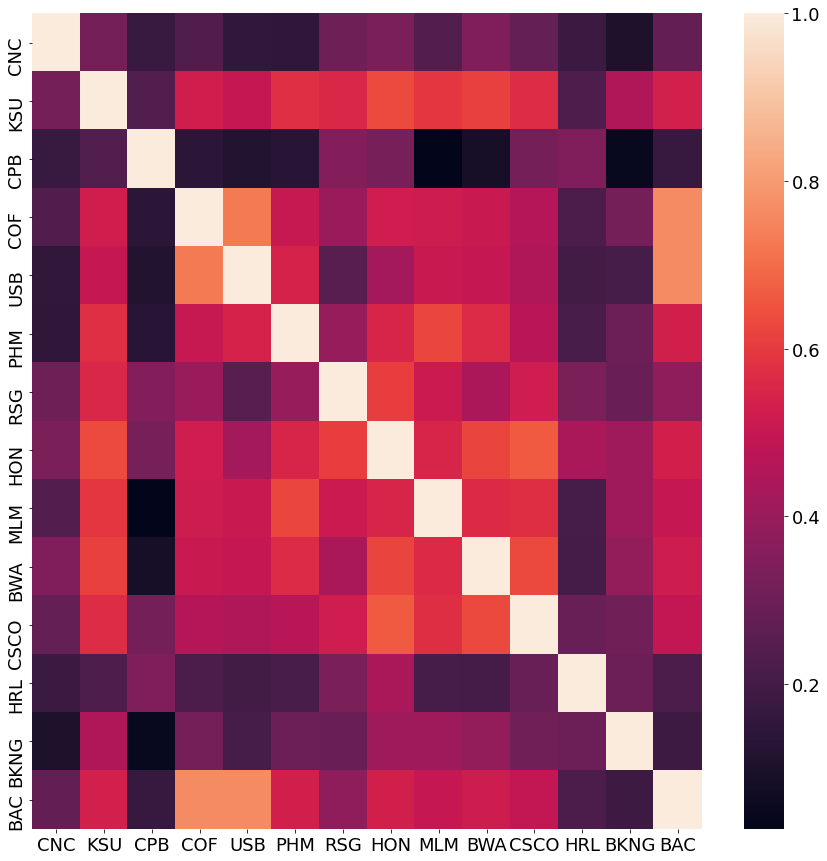

In [61]:
plt.figure(figsize=(15,15))
sns.heatmap(ac_df.iloc[-504:].pct_change(periods=5).dropna().iloc[:,column_indices].corr())
plt.show()

As you can see each of the stocks behave very differently from each other historically.

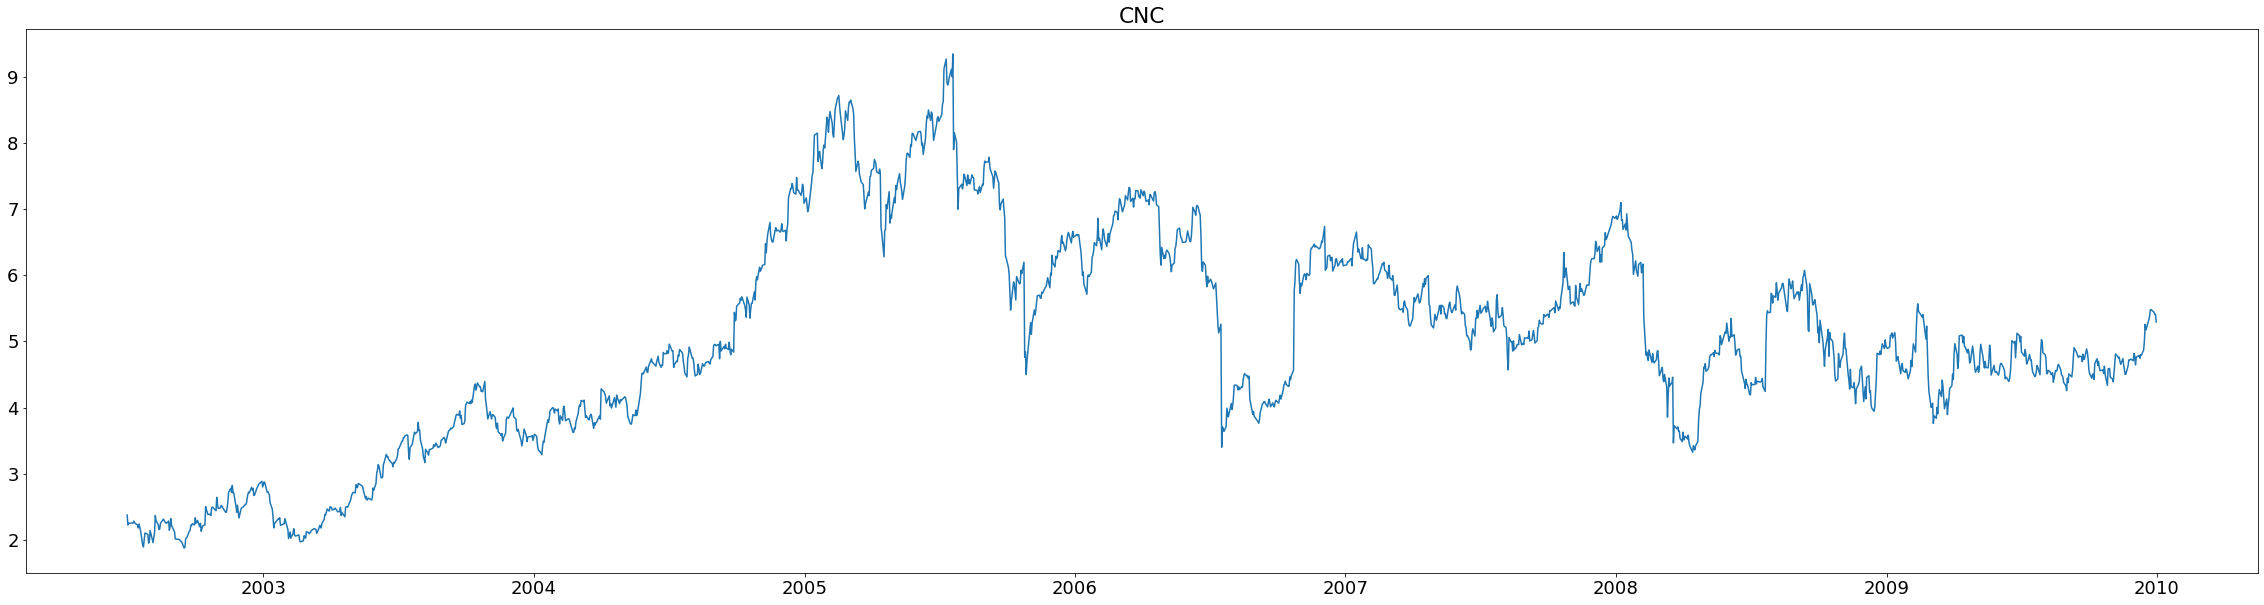

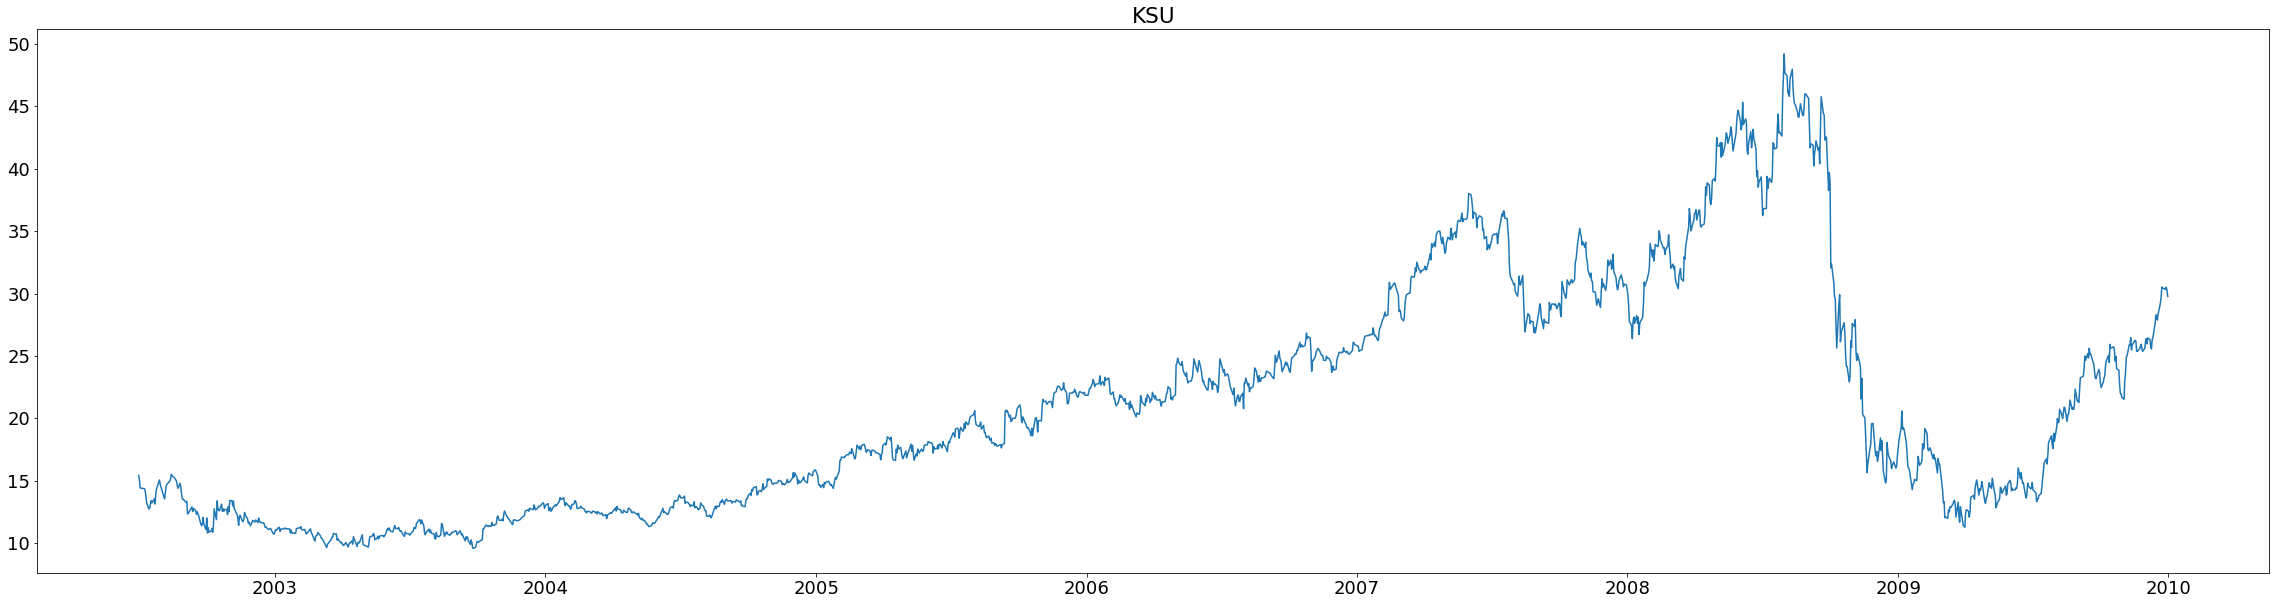

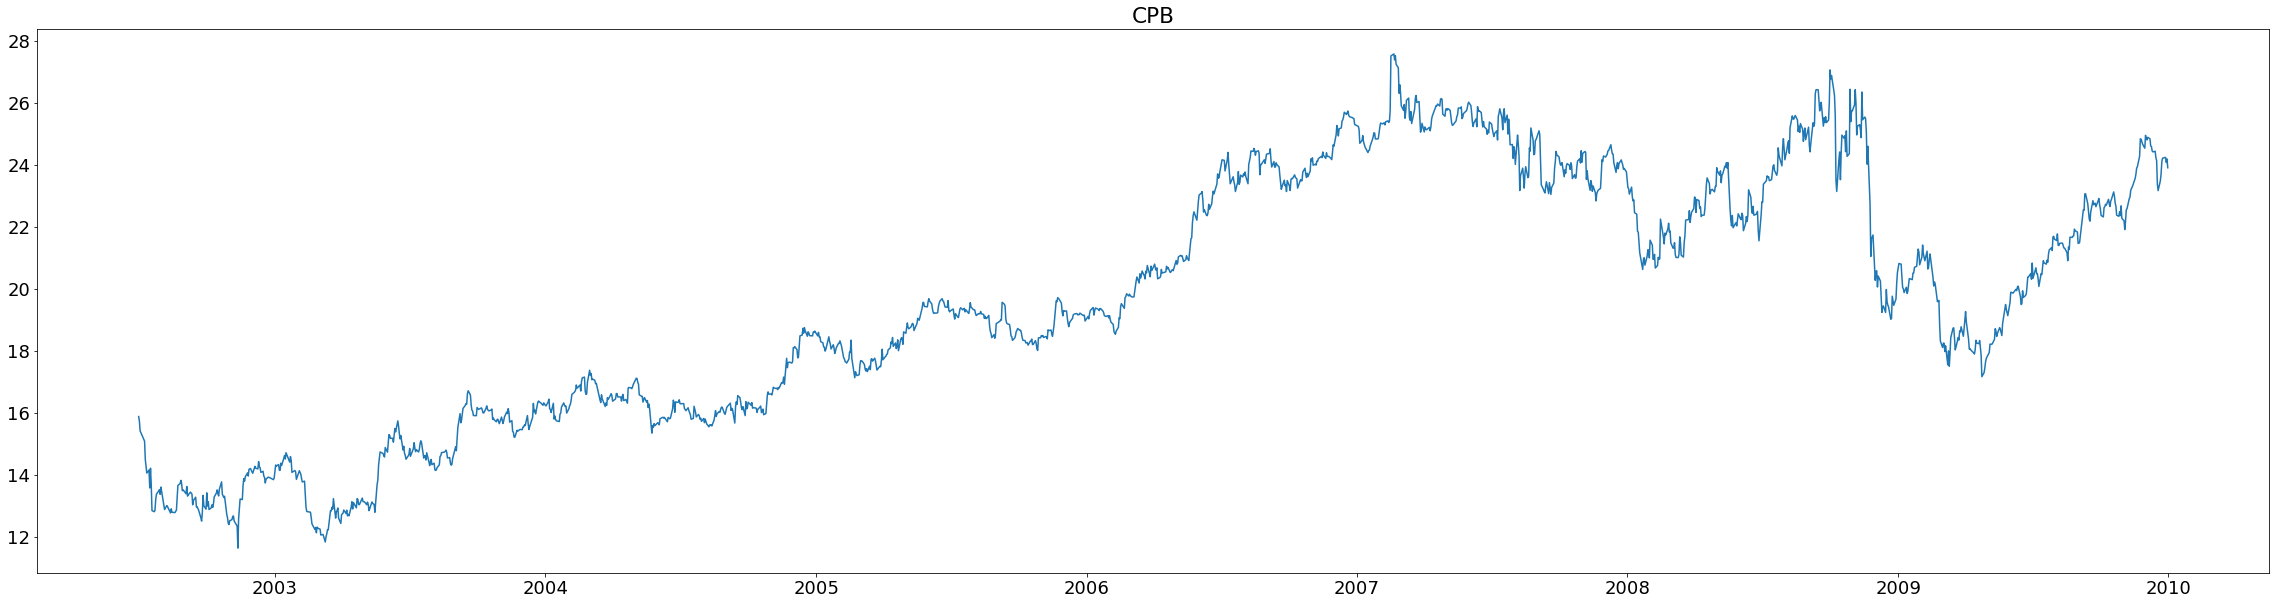

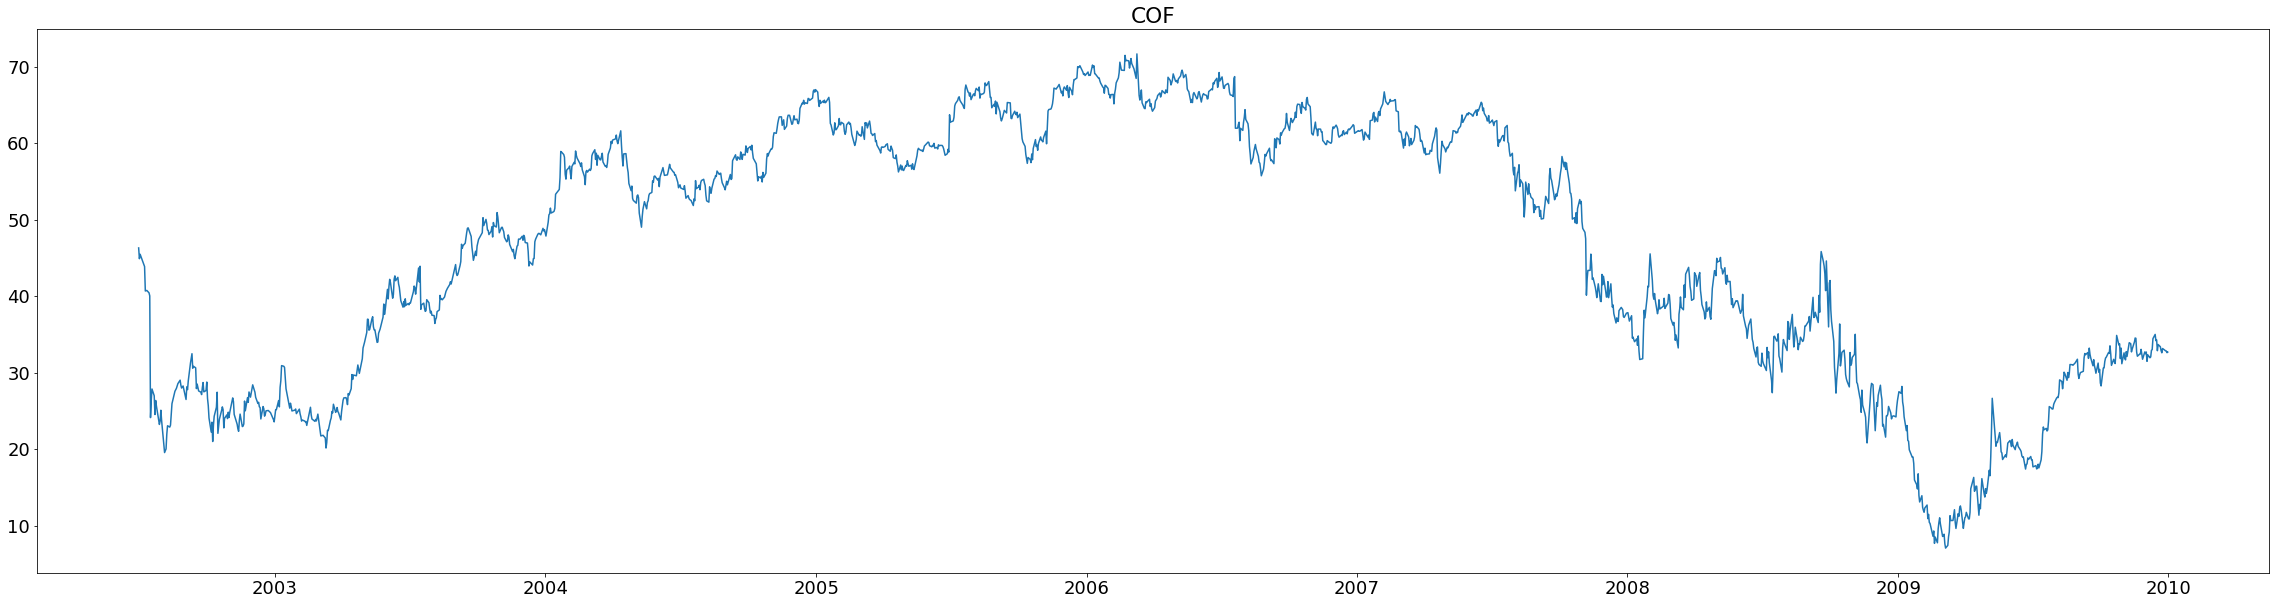

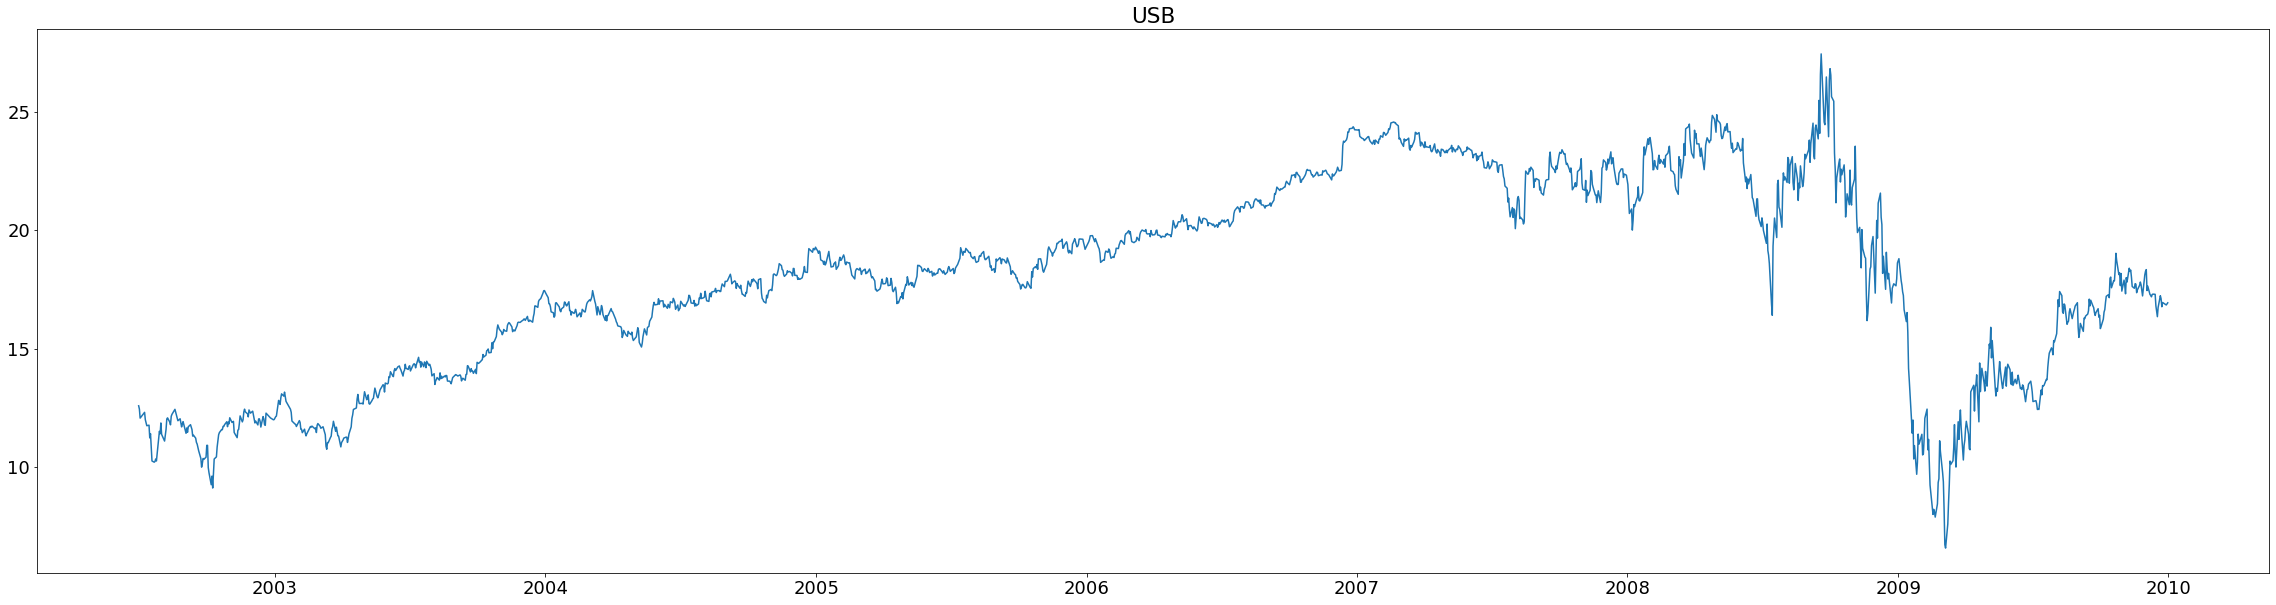

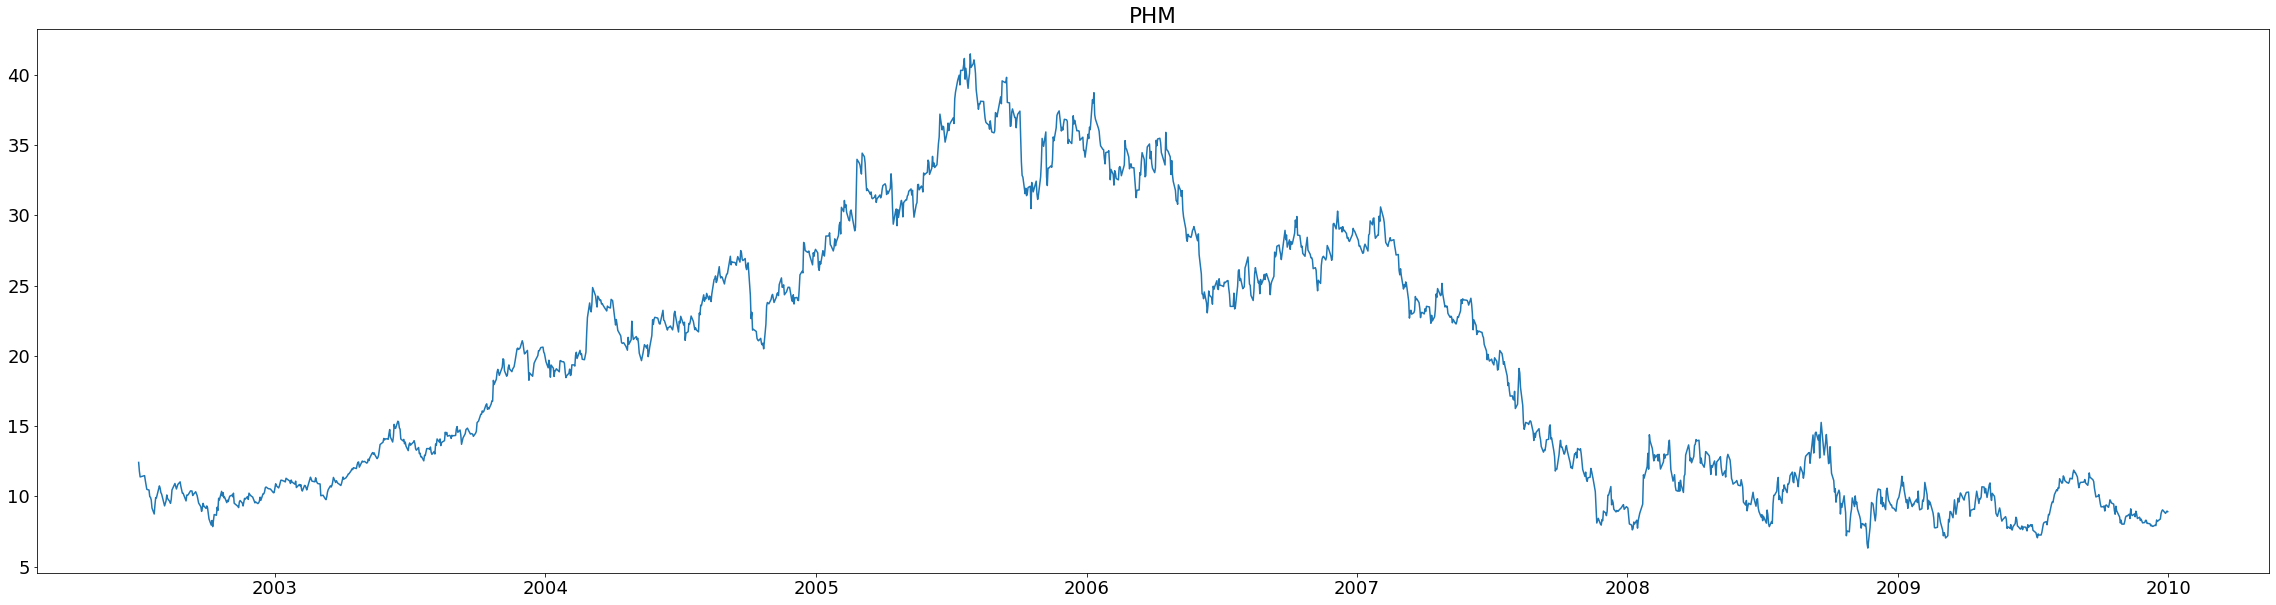

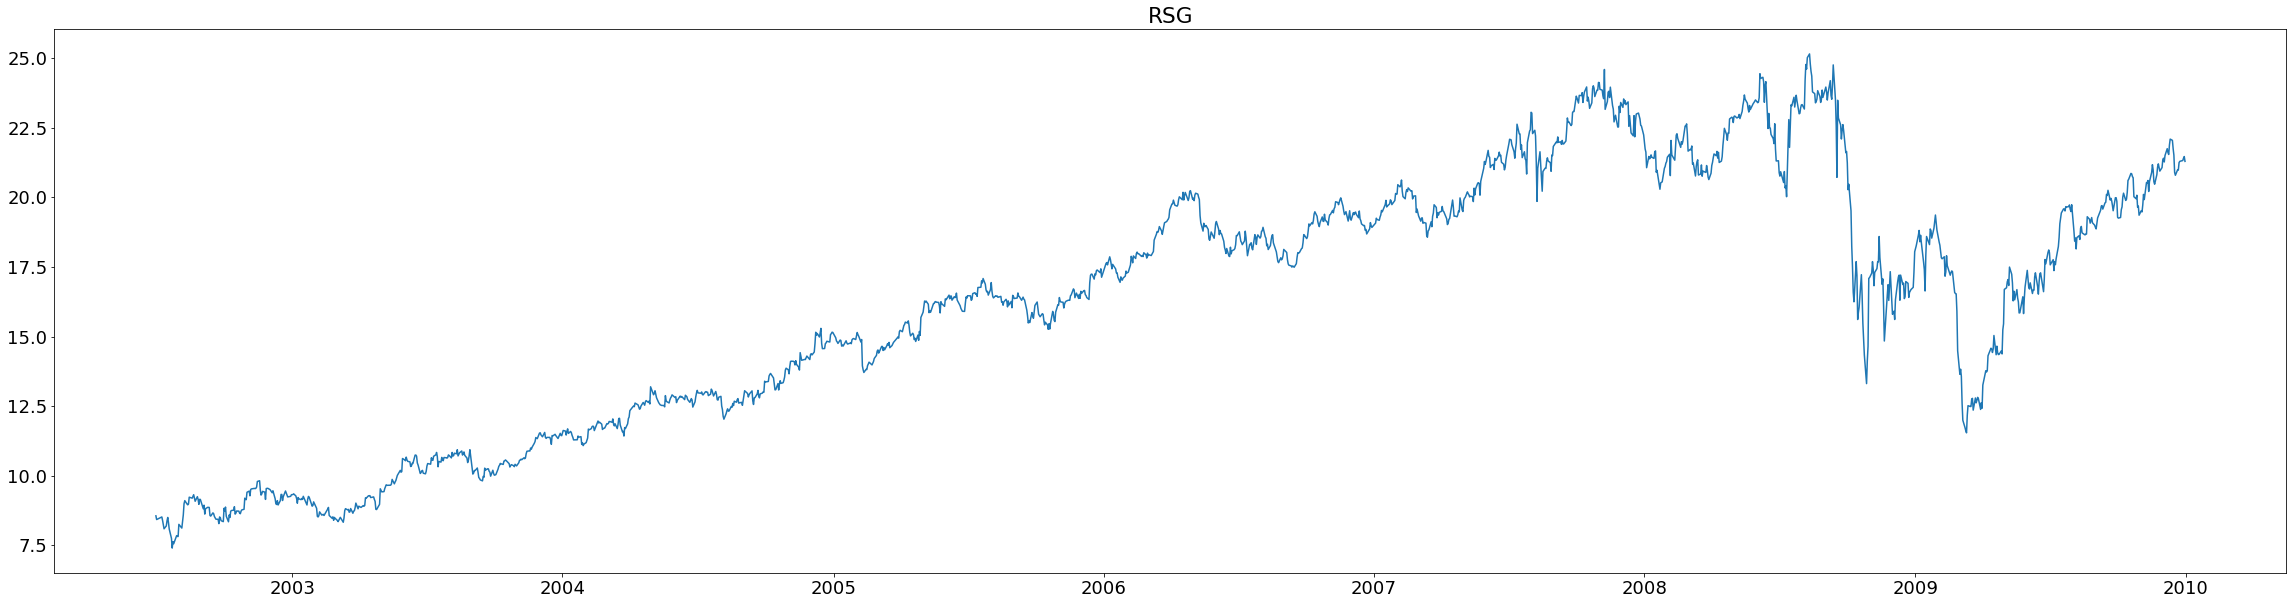

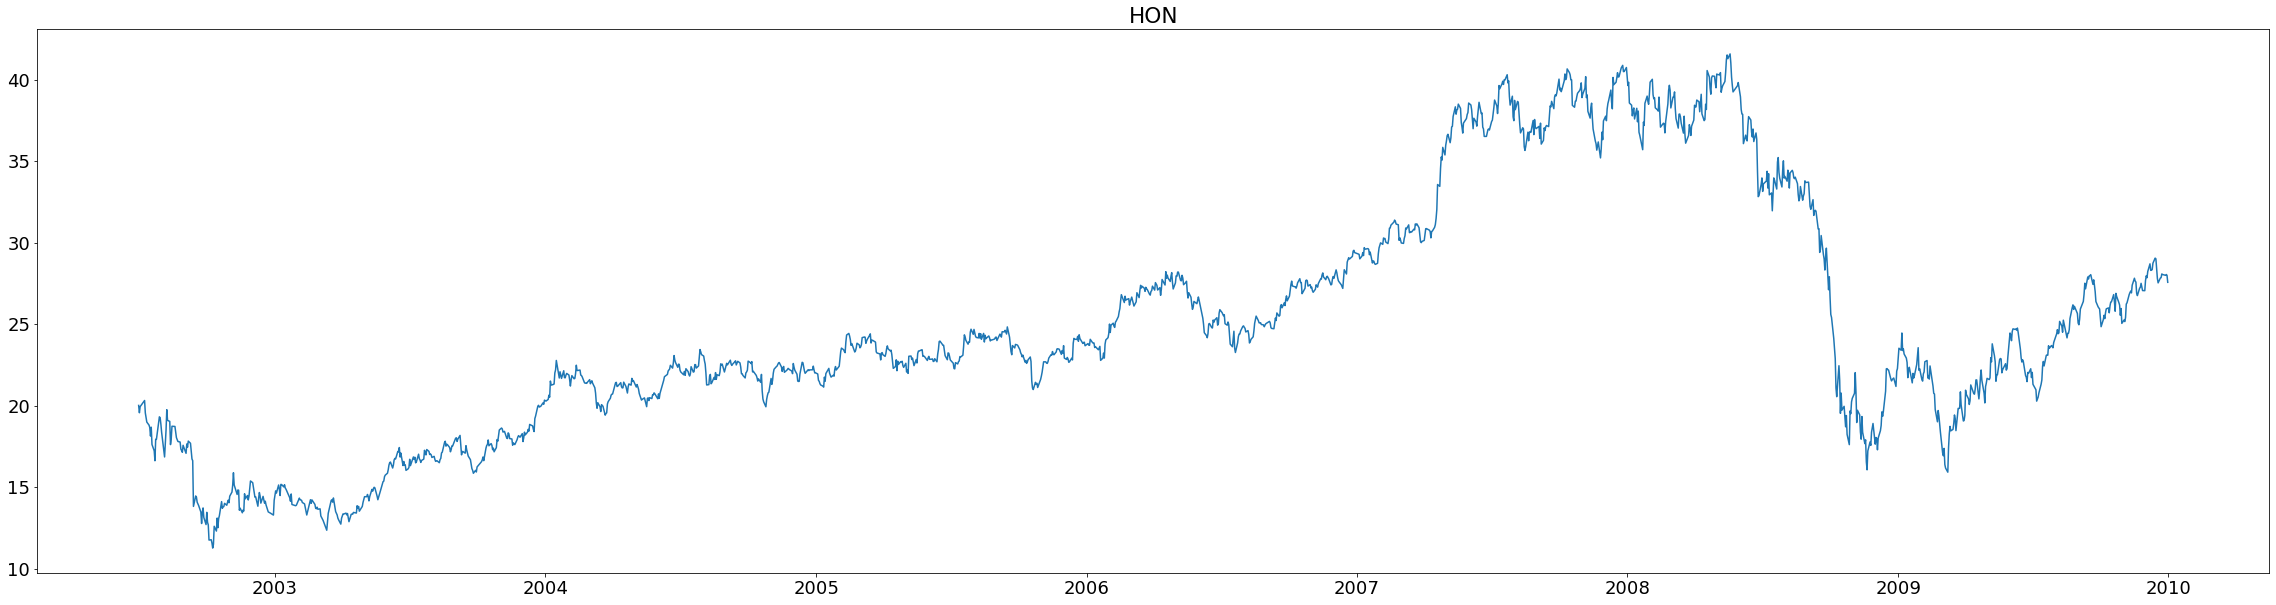

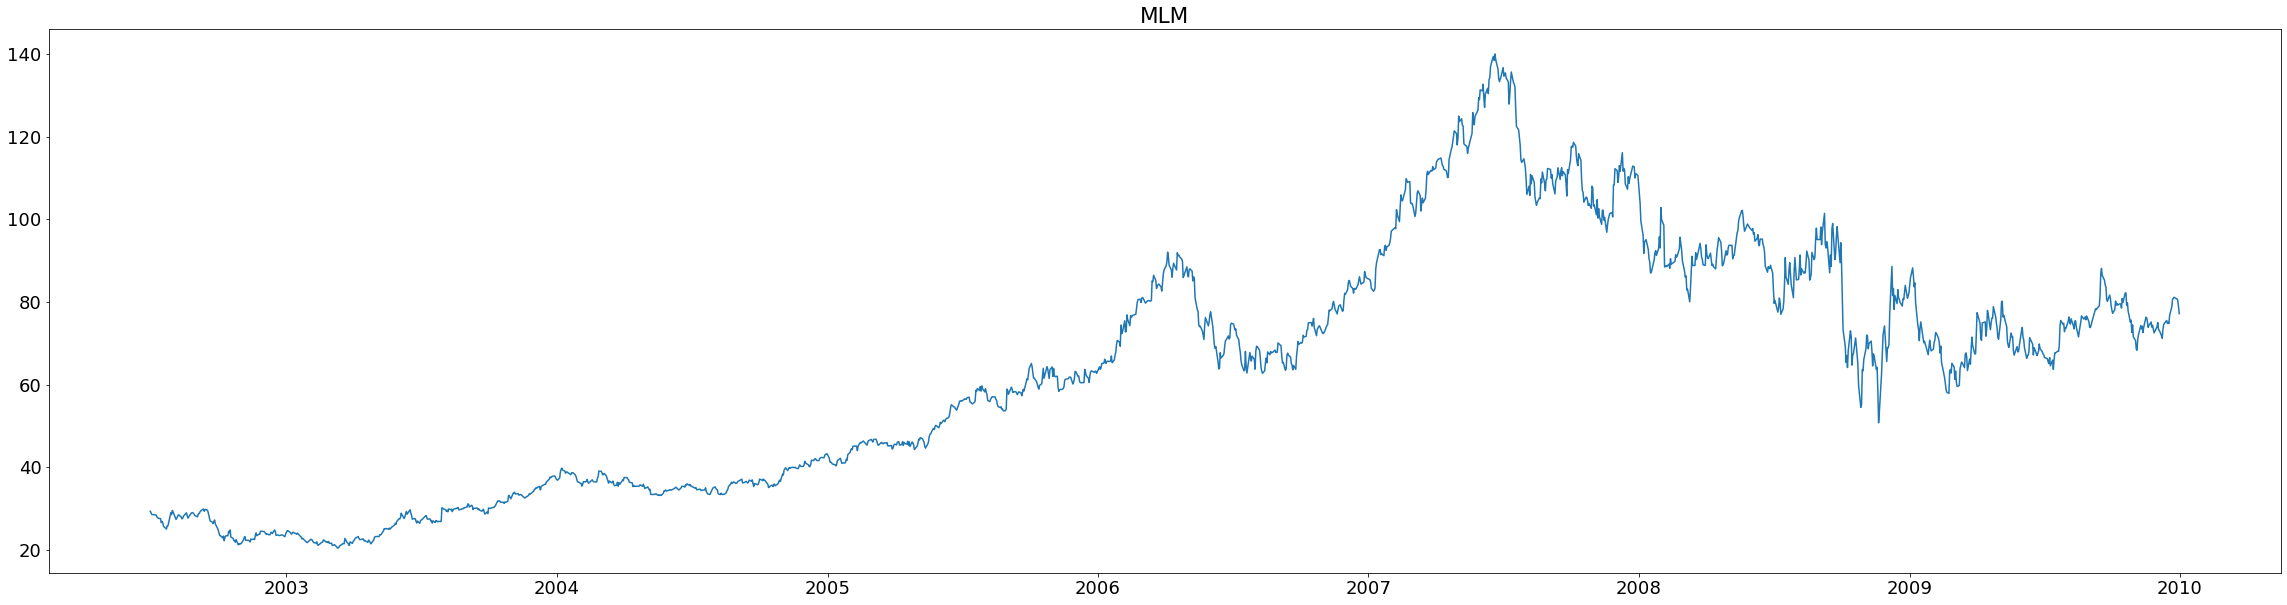

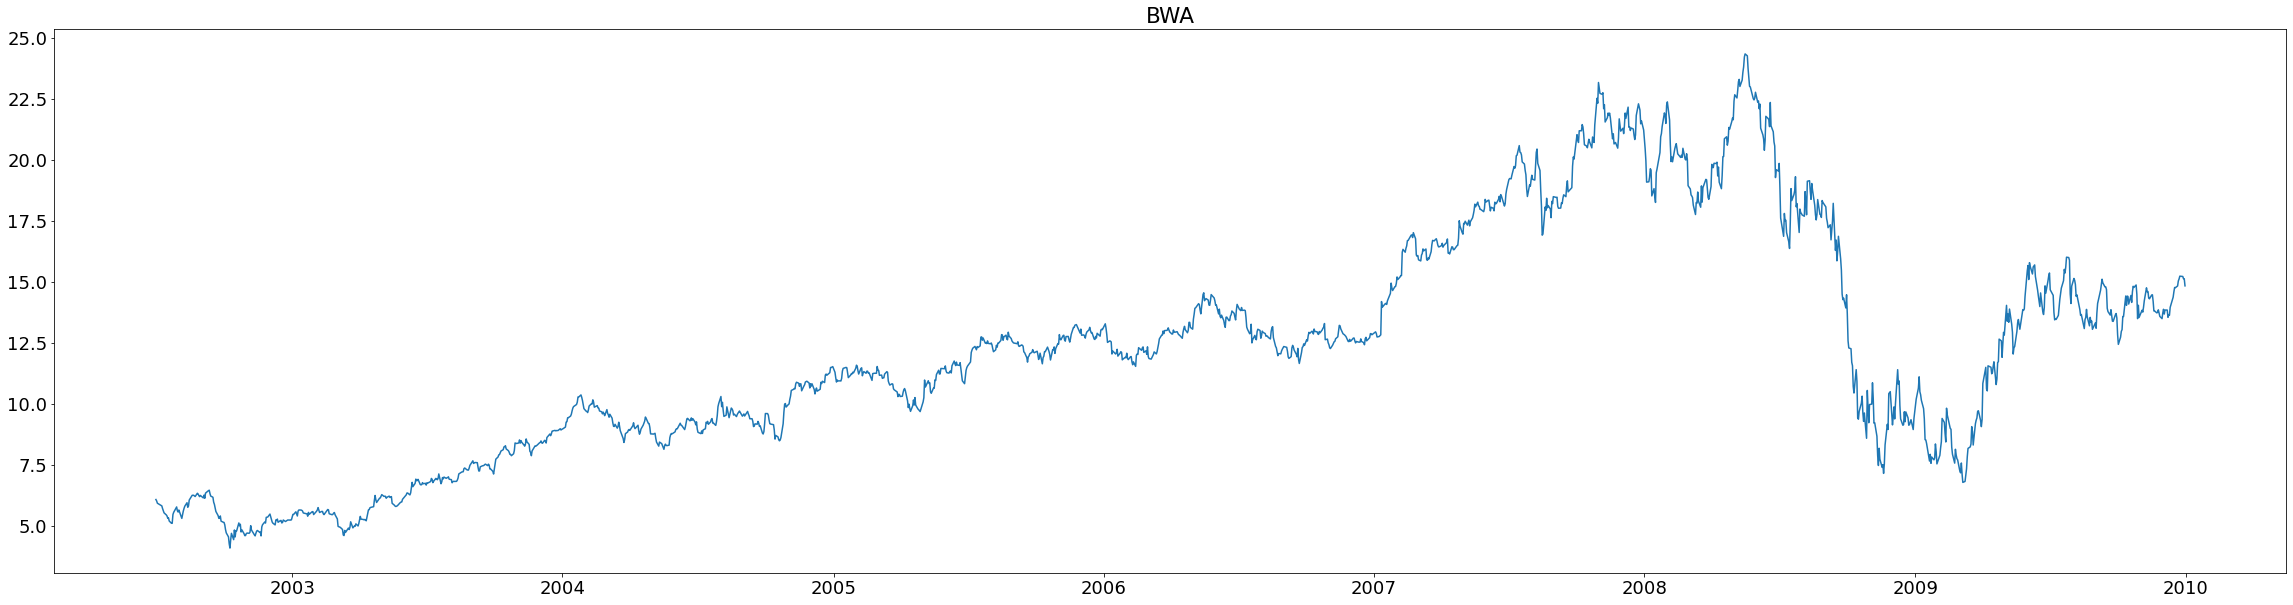

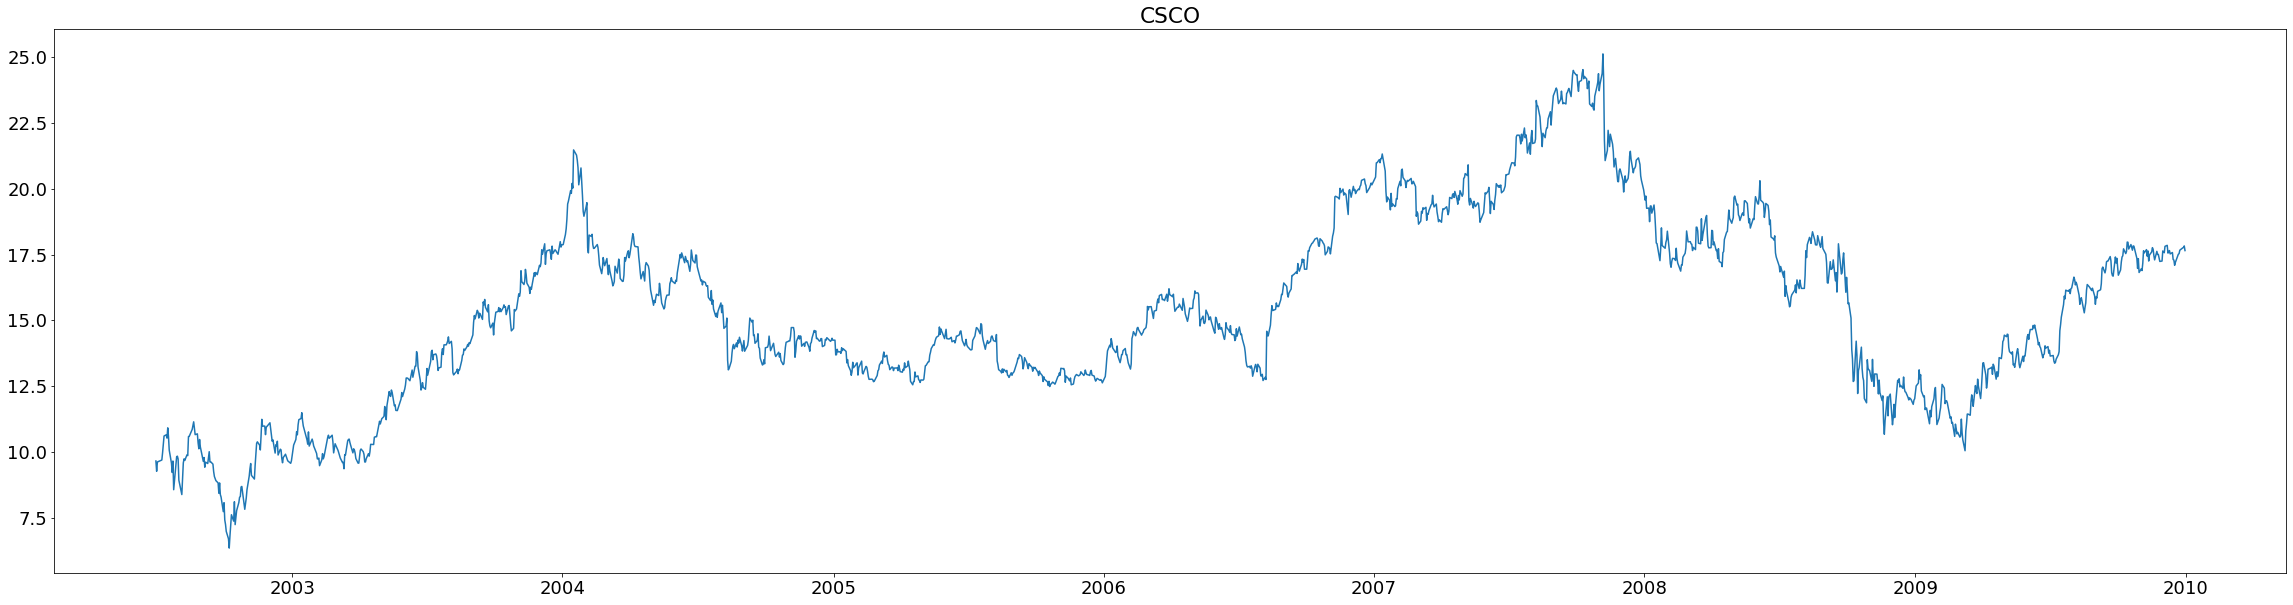

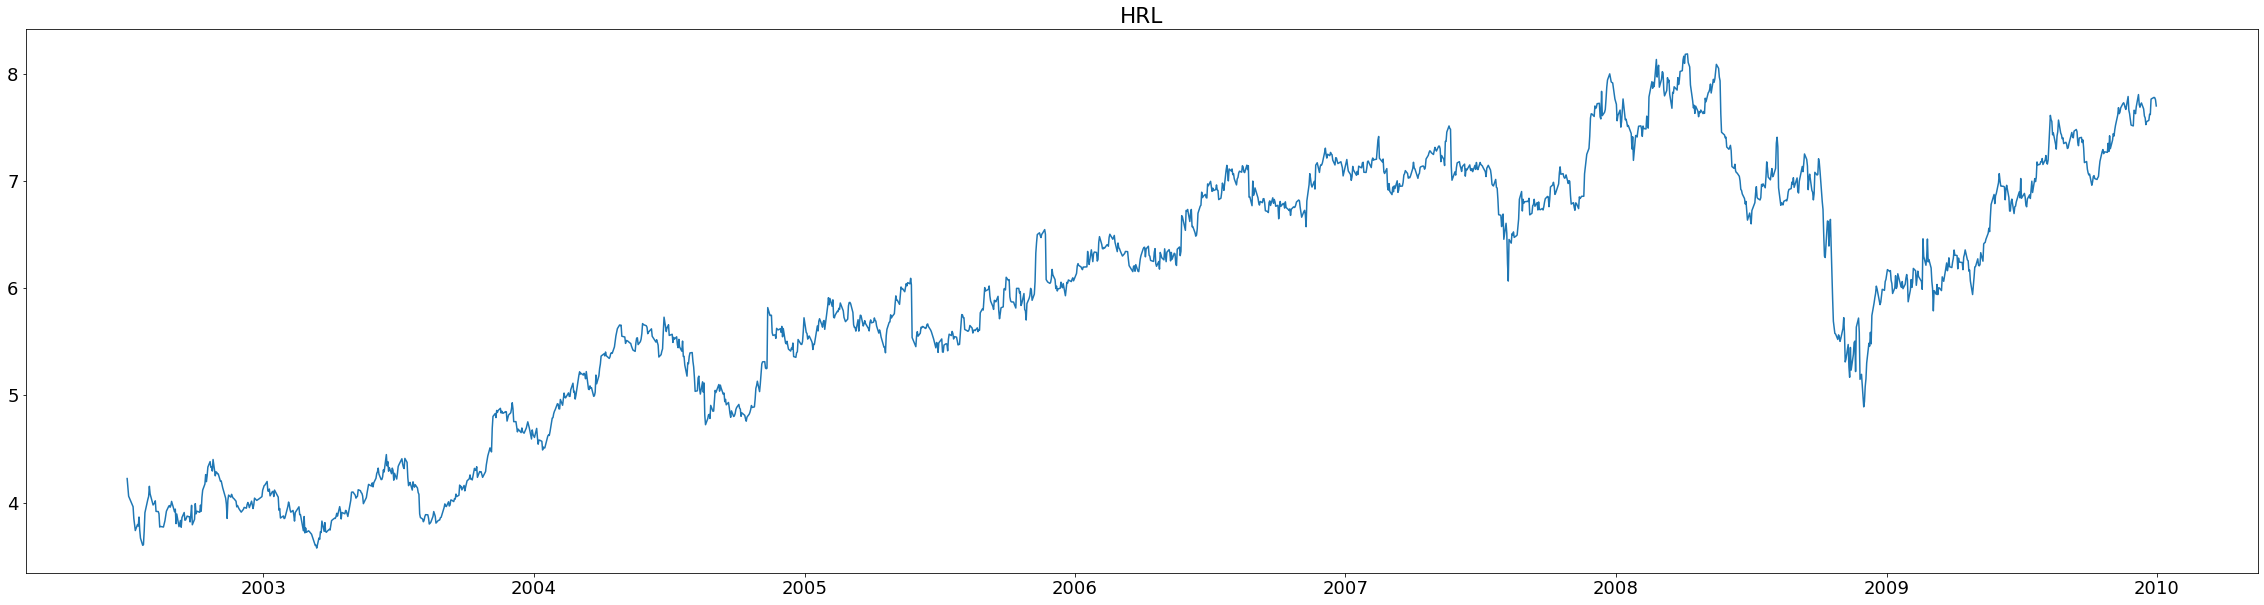

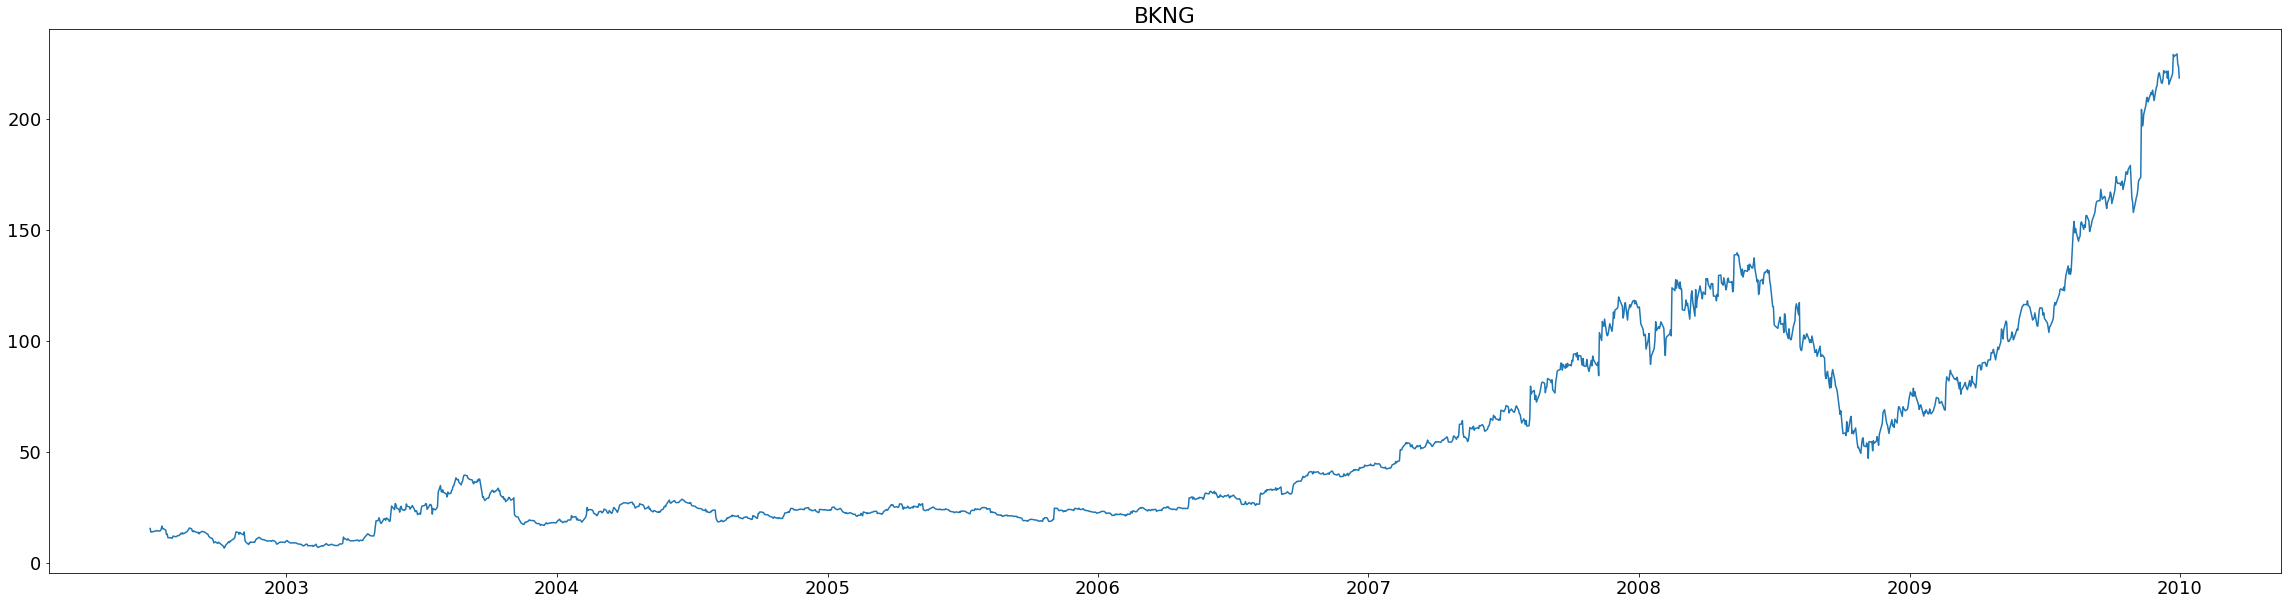

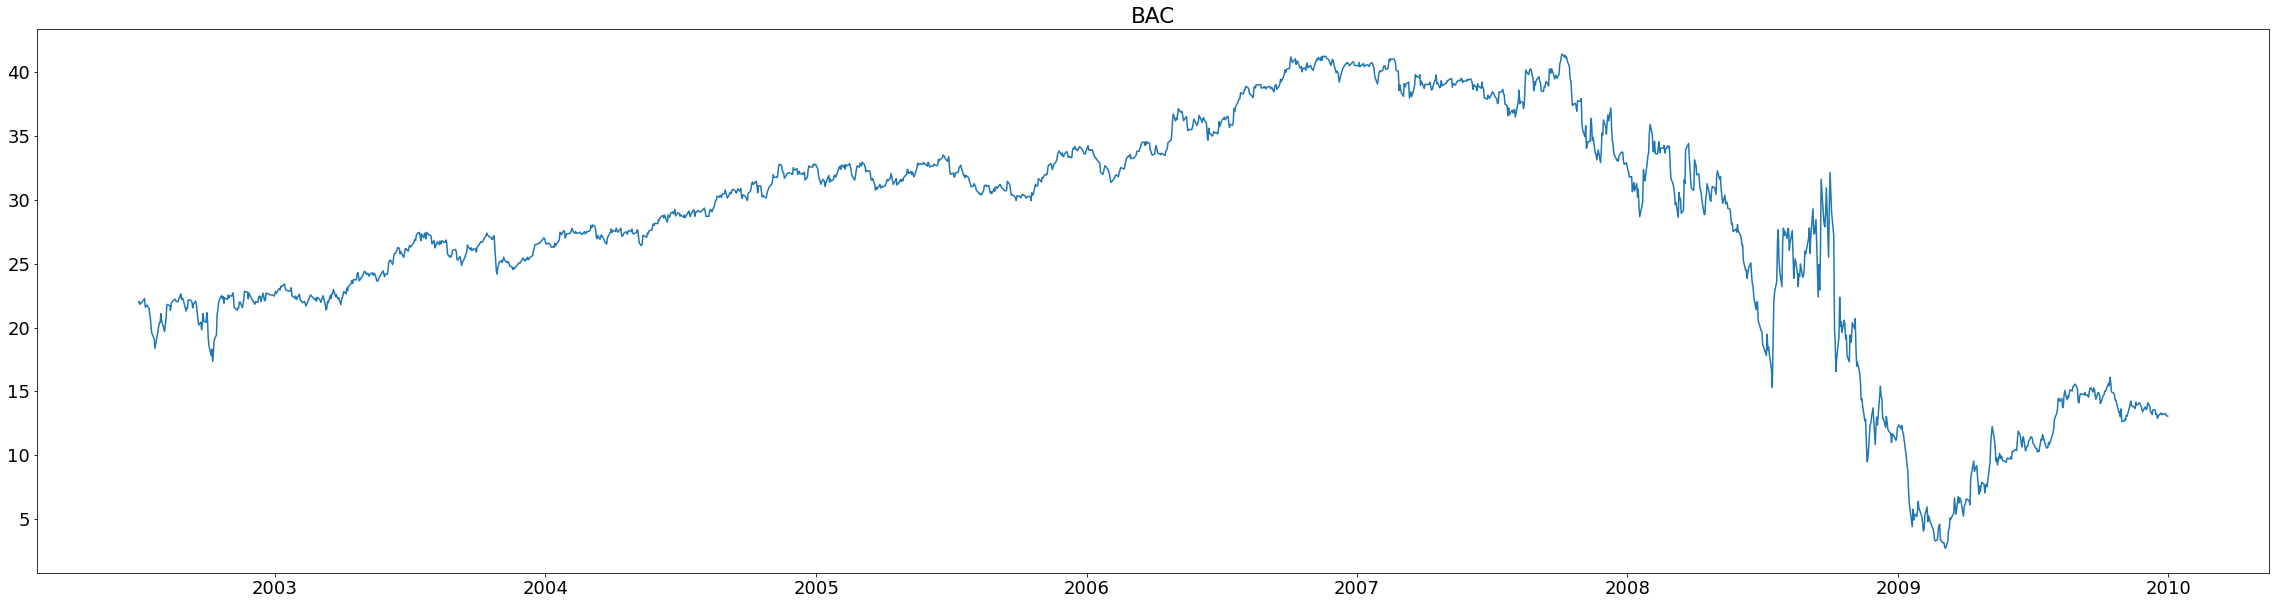

In [62]:
for i in input_final:
    plt.plot(ac_df[i])
    plt.title(str(i).upper())
    plt.show()

In [64]:
#Returns
X = bblock.drop(['target'],axis=1)
y = bblock['target']

In [65]:
X.shape

(16554, 987)

In [66]:
y.shape

(16554,)

I use this XGBRegressor to create my views for the Black-Litteramn portfolio. You can use whichever regressors you believe are best for your purposes.
I do not test my regressions in this portfolio this is as I stated earlier a practical application of machine learning. I have tested and compared regression estimators in other work.

In [68]:
from xgboost import XGBRegressor


xgb = XGBRegressor()
model = xgb.fit(X,y)

In [75]:
str(ac_df.index[0])

'2002-07-01 00:00:00'

In [76]:
market_prices = spy['spy_close']
market_prices.loc['2002-12-06':]

date
2002-12-06     63.8393
2002-12-09     62.0843
2002-12-10     62.9167
2002-12-11     62.9722
2002-12-12     62.9653
                ...   
2021-07-19    424.9700
2021-07-20    431.0600
2021-07-21    434.5500
2021-07-22    435.4600
2021-07-23    439.9400
Name: spy_close, Length: 4689, dtype: float64

In [77]:
ac_df[input_final].loc[str(ac_df.index[0]):]

,CNC,KSU,CPB,COF,USB,PHM,RSG,HON,MLM,BWA,CSCO,HRL,BKNG,BAC
date,,,,,,,,,,,,,,
2002-07-01,2.3750,15.4418,15.8869,46.3262,12.5828,12.4210,8.5572,20.0185,29.3654,6.0836,9.6526,4.2254,15.42,21.9620
2002-07-02,2.2225,15.1197,15.7393,44.9173,12.4443,11.7843,8.4240,19.5694,29.0880,6.0256,9.2618,4.1431,13.86,22.0381
2002-07-03,2.2500,14.4398,15.4239,45.4951,12.0618,11.3899,8.4373,19.9427,28.5870,5.9325,9.6158,4.0609,13.86,21.8193
2002-07-09,2.2542,14.3682,15.0908,43.8884,12.3057,11.4799,8.5172,20.3218,28.4405,5.8217,9.6895,3.9629,14.34,22.2760
2002-07-10,2.2833,14.1356,14.4949,40.6908,11.9953,11.1326,8.3929,19.5577,28.0243,5.7120,9.9623,3.8544,14.52,21.5973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-24,5.4800,30.4631,24.2188,33.1678,16.9496,9.0455,21.2960,28.0515,81.1117,15.2481,17.6682,7.7626,228.00,13.2226
2009-12-28,5.4400,30.3378,24.2435,32.8693,16.8671,8.7960,21.3259,28.0023,80.7234,15.2347,17.7567,7.7787,229.24,13.2573
2009-12-29,5.4075,30.5167,24.0808,32.8438,16.8445,8.8851,21.4081,28.0515,80.3265,15.1453,17.7715,7.7747,224.67,13.1099


In [78]:
views = {}
for i in valid.keys():
    try:
        views[i] = model.predict(valid[i])
    except:
        pass

In [79]:
views['IBM']

array([-0.42499843], dtype=float32)

In [81]:
views['AAPL']

array([-0.95727855], dtype=float32)

In [82]:
input_final

Index(['CNC', 'KSU', 'CPB', 'COF', 'USB', 'PHM', 'RSG', 'HON', 'MLM', 'BWA',
       'CSCO', 'HRL', 'BKNG', 'BAC'],
      dtype='object')

In [83]:
final_views = {}
for i in list(input_final):
    try:
        final_views[i] = views[i]
    except:
        pass
len(final_views.keys())

13

Here we create the risk model with Ledoit Wolf covariance shrinkage.
PyPortfolioOpt has many different risk models which can be used to fulfill the volatility estimation of the efficient frontier.

2.8350320152596415


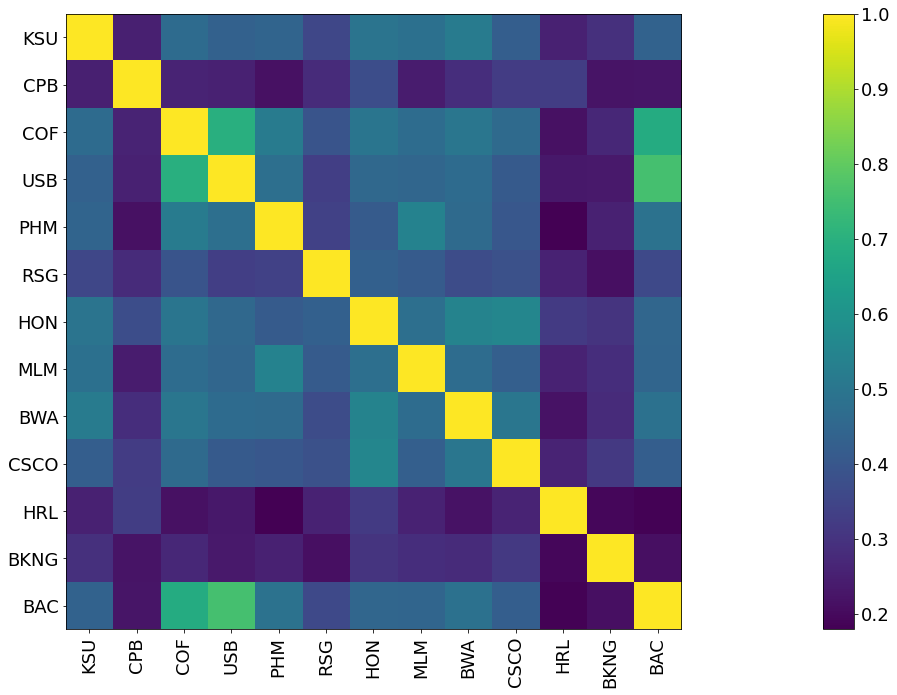

In [84]:
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, plotting

S = risk_models.CovarianceShrinkage(ac_df[final_views.keys()].loc['2002-12-06':]).ledoit_wolf()
delta = black_litterman.market_implied_risk_aversion(market_prices.loc['2002-12-06':])
print(delta)
plotting.plot_covariance(S, plot_correlation=True)
plt.show()

In [88]:
mcap = {}
for i in S.columns:
    mcap[i] = f_dict[i]['commonStock'].loc[str(ac_df.index[-1])]*f_dict[i]['adjusted_close'].loc[ac_df.index[-1]]

In [91]:
mcap['BAC']

1129547523.7

In [92]:
r_df = pd.Series(final_views).T
r_df

KSU       [0.6172163]
CPB      [0.06522981]
COF       [0.5200868]
USB       [0.1936009]
PHM     [-0.06648983]
RSG     [-0.38701543]
HON      [0.16213565]
MLM        [0.548418]
BWA     [-0.55647594]
CSCO     [-0.7889523]
HRL      [-1.0081583]
BKNG      [0.2256408]
BAC      [0.27812314]
dtype: object

In [94]:
latest_prices = pd.Series(ac_df[input_final].iloc[-1])
latest_prices

CNC       5.2925
KSU      29.7831
CPB      23.9110
COF      32.6988
USB      16.9348
PHM       8.9118
RSG      21.2953
HON      27.5732
MLM      77.1511
BWA      14.8503
CSCO     17.6535
HRL       7.6986
BKNG    218.4100
BAC      13.0579
Name: 2009-12-31 00:00:00, dtype: float64

In [96]:
len(S.columns)

13

In [97]:
len(mcap.keys())

13

In [98]:
market_prior = black_litterman.market_implied_prior_returns(mcap, delta, S)
market_prior

KSU     0.195026
CPB     0.085075
COF     0.281147
USB     0.187933
PHM     0.232908
RSG     0.123751
HON     0.184231
MLM     0.175431
BWA     0.215947
CSCO    0.334462
HRL     0.076046
BKNG    0.199726
BAC     0.270386
dtype: float64

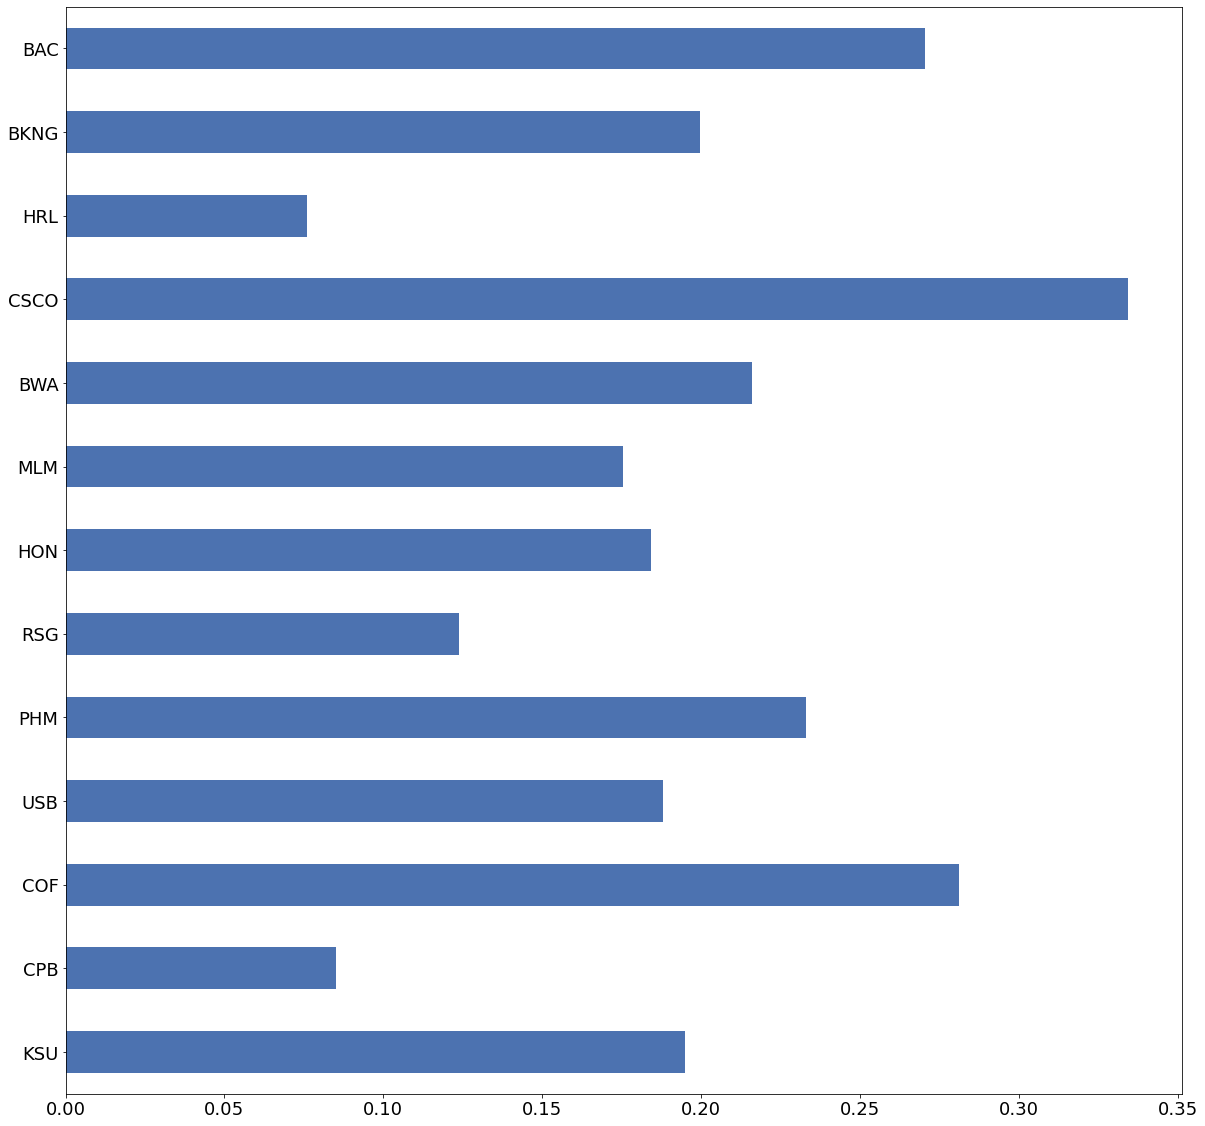

In [99]:
market_prior.plot.barh(figsize=(20,20));

In [100]:
bl = BlackLittermanModel(S, pi=market_prior, absolute_views=final_views)

In [101]:
S_bl = bl.bl_cov()
ret_bl = bl.bl_returns()

In [102]:
ret_bl

KSU     0.203189
CPB    -0.027778
COF     0.202919
USB     0.113848
PHM     0.061599
RSG    -0.171070
HON     0.004368
MLM     0.172316
BWA    -0.157350
CSCO   -0.192312
HRL    -0.450783
BKNG    0.065194
BAC     0.179048
dtype: float64

Here are the key hyperparameters for Black -Litterman, we choose both the weight bounds and gamma.
The weight bounds determine the long short bias of the portfolio. For example, I have chosen no bias (-1,1) so the portfolio could be 100% short any given stock or 100% long any stock or any mix in between.
You could change the weights to (0,1) for example which would be a long only portfolio or create a long bias with say (-0.5,1) to give more emphasis to the long positions, it’s up to you.

Gamma is the regularization parameter, the larger the gamma the more conservative your return estimations will be.

In [103]:
from pypfopt import EfficientFrontier, objective_functions
ef = EfficientFrontier(ret_bl, S_bl,weight_bounds=(-1, 1))
ef.add_objective(objective_functions.L2_reg, gamma = (0.1))
ef.max_sharpe()
weights = ef.clean_weights()
print(weights)

OrderedDict([('KSU', 0.92453), ('CPB', 0.69148), ('COF', 0.34283), ('USB', 0.38134), ('PHM', -0.05016), ('RSG', -0.53362), ('HON', 0.40132), ('MLM', 0.97005), ('BWA', -0.76886), ('CSCO', -0.7715), ('HRL', -1.0), ('BKNG', 0.22871), ('BAC', 0.18387)])


In [104]:
weights = ef.clean_weights()

In [105]:
weights_final = {}
for i in weights.keys():
    if abs(weights[i]) > 0:
        weights_final[i] = weights[i]
    else:
        pass

In [ ]:
weights_final

In [106]:
ef.portfolio_performance(verbose=True,risk_free_rate = 0.02)

Expected annual return: 130.7%
Annual volatility: 79.2%
Sharpe Ratio: 1.62


(1.3066982236965015, 0.7920501271464011, 1.6245161506787695)

I created this custom-made algorithm to predict variance of each individual component based on a Garch model.
These estimations are used to predict Value at risk for the portfolio and therefore control leverage.
The idea is simple, keep VaR below a certain acceptable threshold, you need to determine that risk for yourself.
Honestly I found this to be less efficient than a simple historical variance model like an exponential moving average covariance matrix but it works.

In [107]:
from scipy.stats import norm
def port_var(conf_level,initial_investment,ac_df,weights_final):
    VaR_array = []
    mean= {}
    var = {}
    std_resid = {}

    for i in weights_final.keys():
        try:
            gm = arch_model(ac_df[i],p = 1, q=1,mean = 'constant',vol = 'GARCH',dist = 'normal')
            gm_result = gm.fit()
            gf = gm_result.forecast(horizon=10)
            std_resid[i] = gm_result.std_resid
            mean[i] = gf.mean['h.01'].iloc[-1]
            var[i] = gf.variance['h.01'].iloc[-1]
        except:
            pass
    for i in var.keys():
        VaR_array.append(mean[i]+(np.sqrt(var[i])*(std_resid[i].quantile(conf_level))))
    vector = np.array(VaR_array)
    ret = ac_df[var.keys()]
    corr_matrix = ret.cov()
    avg_ret = ret.mean()
    wf = pd.Series(weights_final)
    port_mean =avg_ret.dot(wf[ret.columns])
    port_stdev = np.sqrt(wf[ret.columns].T.dot(corr_matrix).dot(wf[ret.columns]))
    mean_investment = (1+port_mean) * initial_investment
    stdev_investment = initial_investment * port_stdev
    cutoff = norm.ppf(conf_level, mean_investment, stdev_investment)
    port_var = initial_investment - cutoff
    return(corr_matrix, float(port_var))

In [108]:
aca_df = ac_df.iloc[-500:].pct_change(periods=1).dropna()

In [109]:
corr_matrix, port = port_var(0.05,20000,aca_df,weights_final)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 482302874.8258984
Iteration:      2,   Func. Count:     17,   Neg. LLF: 4220599.086239186
Iteration:      3,   Func. Count:     27,   Neg. LLF: -957.1588961173275
Optimization terminated successfully    (Exit mode 0)
            Current function value: -957.1588954464542
            Iterations: 7
            Function evaluations: 27
            Gradient evaluations: 3
Iteration:      1,   Func. Count:      6,   Neg. LLF: 472005837.4795323
Iteration:      2,   Func. Count:     18,   Neg. LLF: 28648102115084.42
Iteration:      3,   Func. Count:     28,   Neg. LLF: -1373.3084931320332
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1373.3084950574578
            Iterations: 7
            Function evaluations: 28
            Gradient evaluations: 3
Iteration:      1,   Func. Count:      6,   Neg. LLF: 357698.86554645695
Iteration:      2,   Func. Count:     17,   Neg. LLF: 942.1957651040866
Ite

In [110]:
#VaR estimation
port

2356.6952150142242

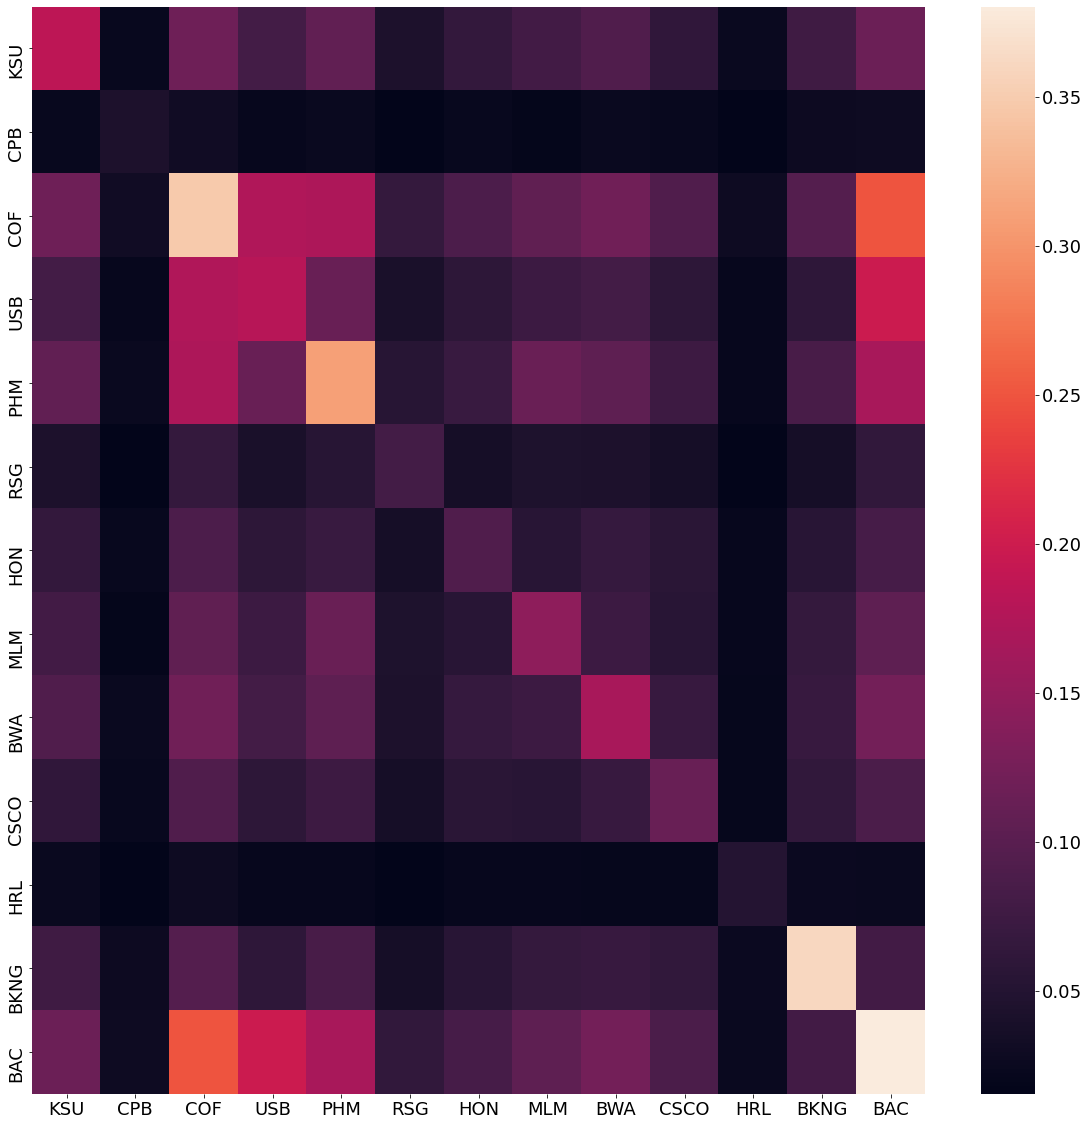

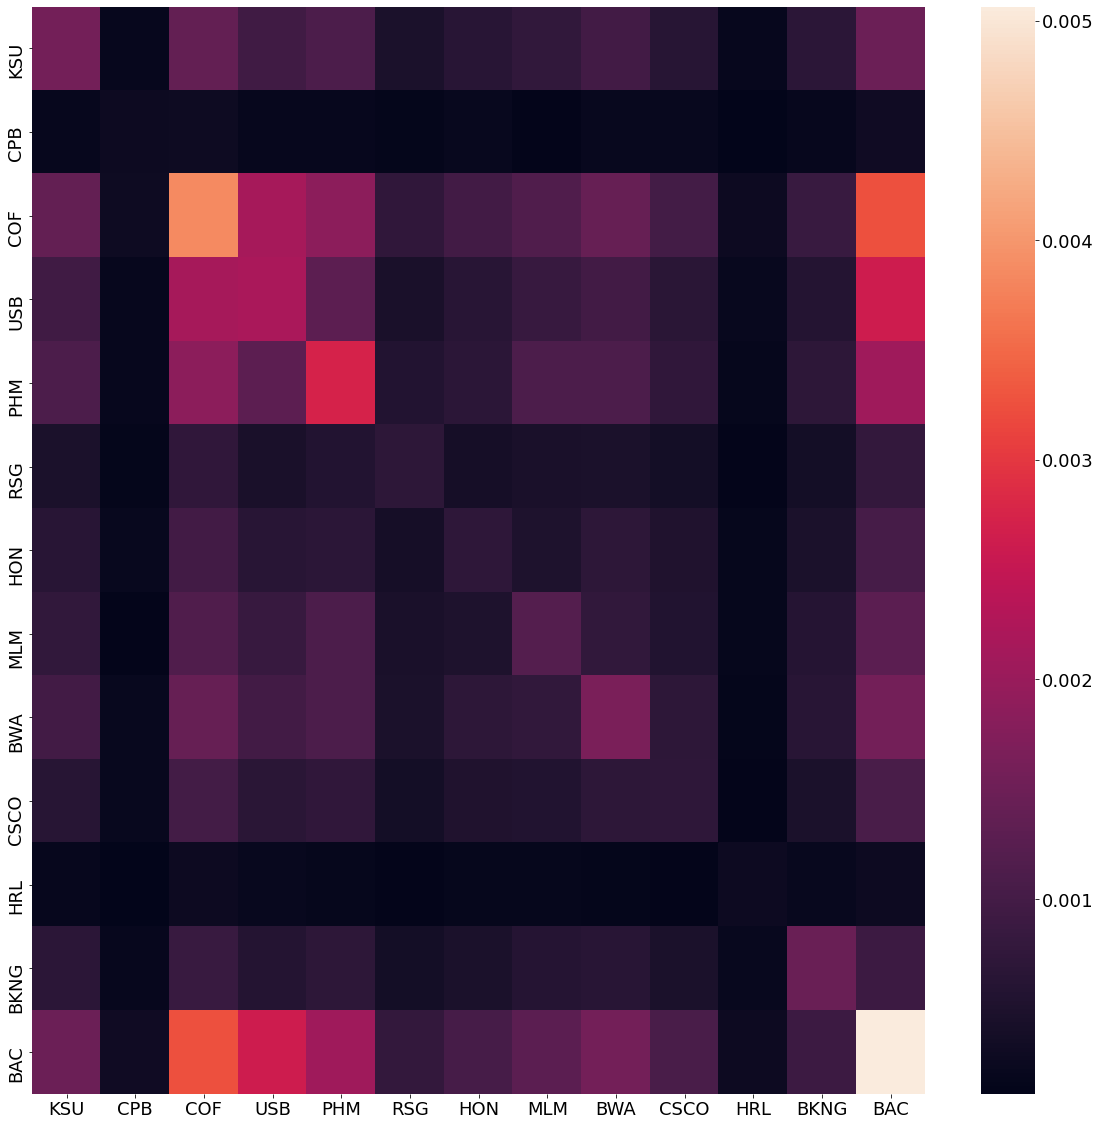

In [111]:
plt.figure(figsize=(20,20))
sns.heatmap(S)
plt.show()
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix)
plt.show()

In [112]:
weights_final = pd.Series(weights_final)
weights_final

KSU     0.92453
CPB     0.69148
COF     0.34283
USB     0.38134
PHM    -0.05016
RSG    -0.53362
HON     0.40132
MLM     0.97005
BWA    -0.76886
CSCO   -0.77150
HRL    -1.00000
BKNG    0.22871
BAC     0.18387
dtype: float64

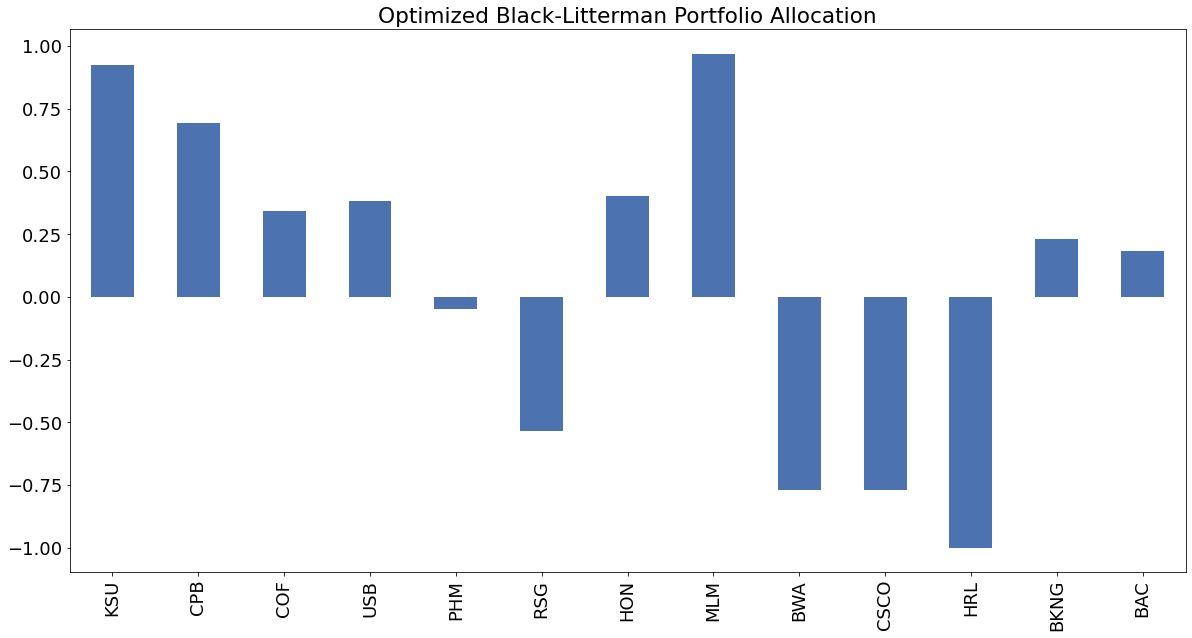

In [113]:
pd.Series(weights_final.plot.bar(figsize=(20,10)))
plt.title('Optimized Black-Litterman Portfolio Allocation')
plt.show()

In [114]:
lates = latest_prices.filter(weights_final.keys())
lates  

KSU      29.7831
CPB      23.9110
COF      32.6988
USB      16.9348
PHM       8.9118
RSG      21.2953
HON      27.5732
MLM      77.1511
BWA      14.8503
CSCO     17.6535
HRL       7.6986
BKNG    218.4100
BAC      13.0579
Name: 2009-12-31 00:00:00, dtype: float64

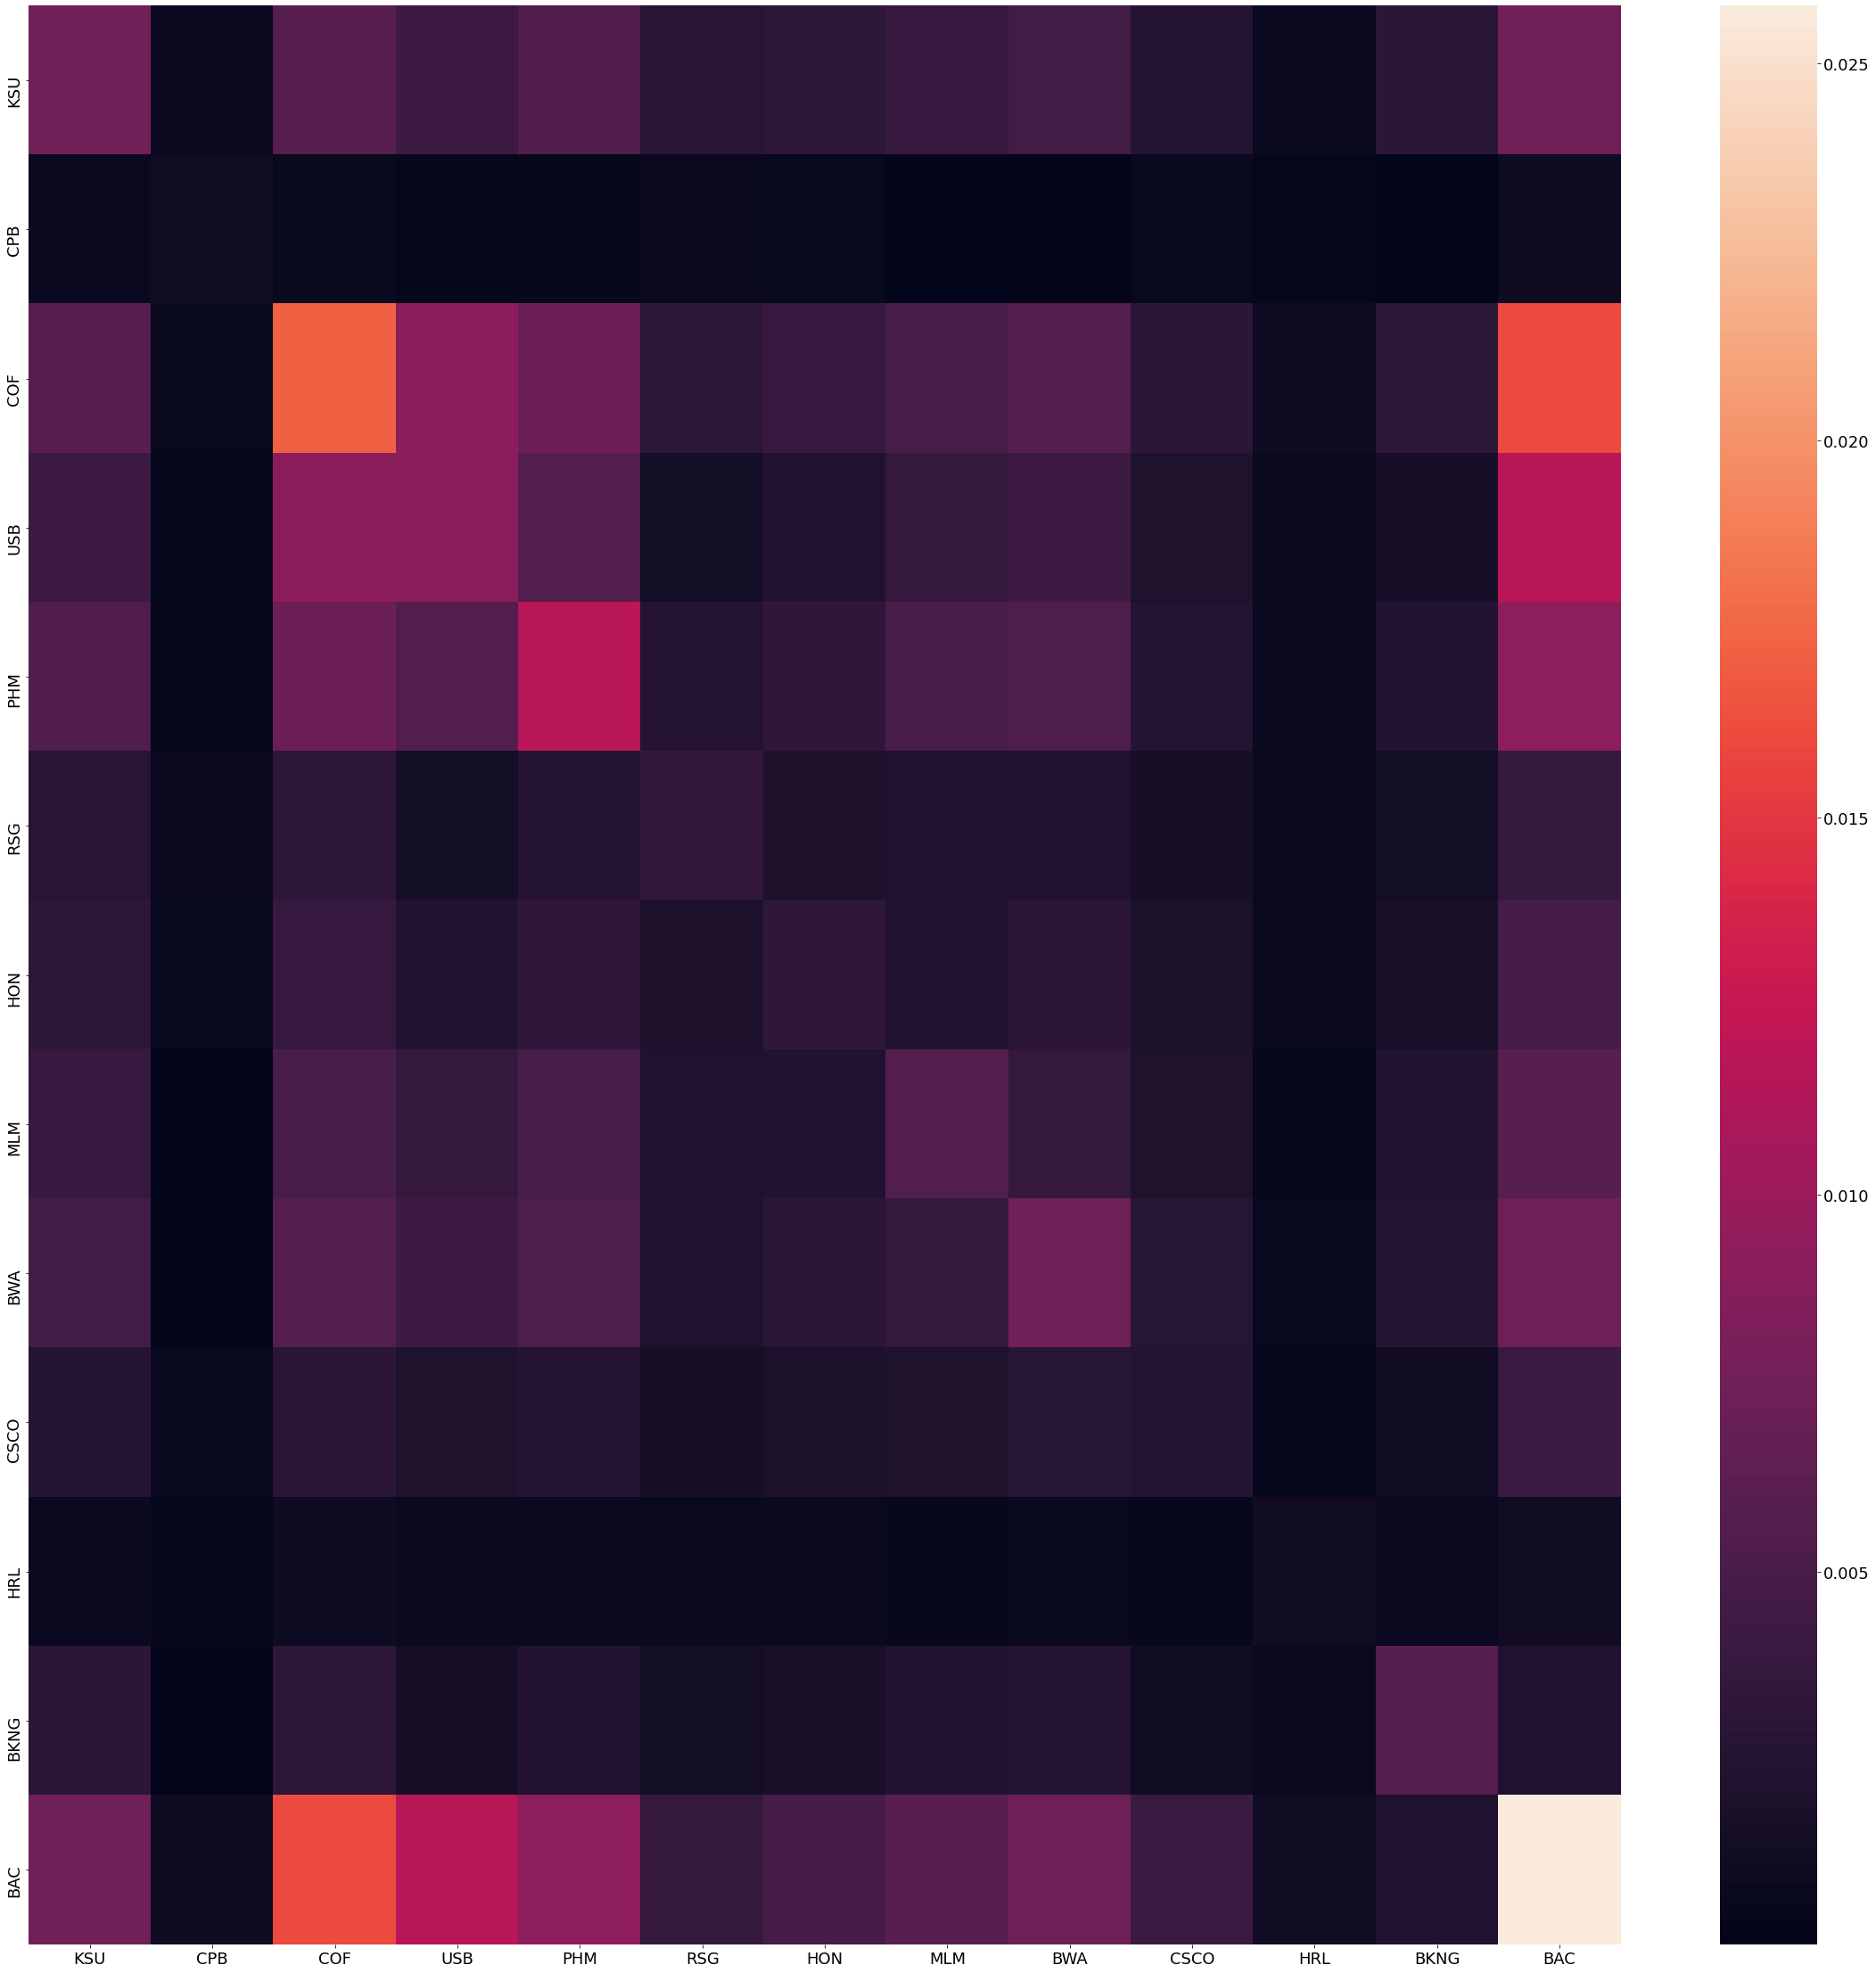

In [116]:
ac_df = ac_df.iloc[-500:].dropna()
daily_returns = ac_df.pct_change(periods=5)
port_returns = daily_returns.filter(weights_final.keys())
corr_matrix = (port_returns.dropna()).cov()
plt.figure(figsize=(40,40))
sns.heatmap(corr_matrix)
plt.show()

In [117]:
weights_final = {}
for i in weights.keys():
    if abs(weights[i]) > 0:
        weights_final[i] = weights[i]
    else:
        pass

In [118]:
print('end: ' ,ac_df.index[-1])

end:  2009-12-31 00:00:00


In [119]:
from pypfopt.discrete_allocation import DiscreteAllocation

da = DiscreteAllocation(weights_final, lates, total_portfolio_value=20000,short_ratio = 0.2)
alloc, leftover = da.lp_portfolio()
print(alloc)

{'KSU': 150, 'CPB': 141, 'COF': 51, 'USB': 109, 'HON': 71, 'MLM': 61, 'BKNG': 5, 'BAC': 68, 'PHM': -7, 'RSG': -32, 'BWA': -66, 'CSCO': -56, 'HRL': -167}


I used the below code as a crude type of back test. You can loop through the entire notebook each quarter, create a new portfolio and test that quarter’s results. It works as a simple walk forward validation.

In [120]:
cash_diff = {}
for k,v in alloc.items():
    st_p = ohlc_df[k]['adjusted_close'].loc['2010-01-04']
    en_p = ohlc_df[k]['adjusted_close'].loc['2010-04-05']
    if v < 0:
        cash_diff[k] = (st_p * abs(v)) - (en_p * abs(v))
    else:
        cash_diff[k] =  (en_p * abs(v)) -(st_p * abs(v))
cash_df = pd.Series(cash_diff)
cash_df.sum()

1125.7715999999996